# 🏦 WealthWise AI — Feature Engineering Pipeline
### Notebook 02: Transforming Clean Data into ML-Ready Features

---

## 📋 Table of Contents

| Section | Topic |
|---------|-------|
| 1 | Project Introduction |
| 2 | Import Libraries |
| 3 | Load Datasets |
| 4 | Data Validation |
| 5 | Monthly Income Feature |
| 6 | Monthly Expense Feature |
| 7 | Savings Feature |
| 8 | Savings Rate Feature |
| 9 | Balance Features |
| 10 | Transaction Activity Features |
| 11 | Category Spending Features |
| 12 | Income Consistency Feature |
| 13 | Expense Stability Feature |
| 14 | Financial Behaviour Features |
| 15 | Smart Alert Features |
| 16 | Final Feature Table Assembly |
| 17 | Visualization Suite |
| 18 | Export |

---

> **Author:** WealthWise AI Engineering Team  
> **Version:** 1.0.0  
> **Date:** June 2026  
> **Status:** Production-Ready

---

# Section 1 — Project Introduction

---

## 🚀 WealthWise AI: Platform Overview

**WealthWise AI** is an AI-powered personal finance platform that ingests raw bank statements and delivers:

| Module | Description |
|--------|-------------|
| 📊 Financial Analytics Dashboard | Visual spending/income breakdowns |
| 🩺 Financial Health Score | Composite health scoring engine |
| 🤖 ML Risk Classification | Random Forest–based risk categorisation |
| 📈 Portfolio Recommendation | Rule + ML–driven investment suggestions |
| 🧠 AI Financial Coach | Gemini-powered conversational advisor |

---

## 🔧 What is Feature Engineering?

**Feature Engineering** is the process of using domain knowledge to transform raw data into **informative, discriminative, and interpretable features** that machine learning models can learn from.

Raw bank transactions tell you *what happened*. Features tell you *what it means*.

```
Raw Data → Cleaning → Feature Engineering → ML-Ready Dataset
   │                        │
   │                        ├── Aggregations (monthly income, expense)
   │                        ├── Ratios      (savings rate, spending ratio)
   │                        ├── Stability   (income CV, expense CV)
   │                        └── Flags       (high spending, low savings)
```

---

## 🎯 Why Feature Engineering Matters for WealthWise AI

### 1. Financial Health Score
The health score is a **weighted composite** of savings rate, income stability, expense control, and liquidity. Each of these is a *derived feature*, not a raw column.

### 2. Random Forest Risk Classification
Tree-based models need **numeric, tabular features** — not raw transaction logs. Features like `spending_to_income_ratio` and `savings_rate` give the model meaningful signal.

### 3. Portfolio Recommendation
The recommendation engine needs to understand a user's **risk capacity**, **disposable income**, and **investment regularity** — all derived from engineered features.

### 4. AI Financial Coach
The Gemini-powered coach enriches its responses with **quantified insights** — e.g., 'Your savings rate dropped 12% this month compared to your 3-month average.'

---

## 📐 Feature Granularity

All features are engineered at the **`account_number` × `month_year`** level — one row per account per month.

This grain:
- Captures **temporal trends** (monthly patterns over time)
- Supports **per-account personalisation**
- Is the correct grain for the Financial Health Score and ML Risk Model

---

## 🗂️ Input → Output

```
INPUT
  ├── transactions_clean.csv   (16,000+ transaction rows)
  ├── accounts_clean.csv       (100 account records)
  └── bank_statements_clean.csv

OUTPUT
  └── features_dataset.csv     (account × month feature table)
```

---

# Section 2 — Import Libraries

---

We import only the libraries specified for this project. All functions are self-contained and importable by FastAPI or downstream ML modules.

In [1]:
# =============================================================================
# SECTION 2: LIBRARY IMPORTS
# =============================================================================

# Standard library
import os
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Suppress non-critical warnings ──────────────────────────────────────────
warnings.filterwarnings('ignore')

# ── Display settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)        # Show all columns
pd.set_option('display.max_colwidth', 60)          # Reasonable column width
pd.set_option('display.float_format', '{:,.2f}'.format)  # Comma-formatted floats
pd.set_option('display.width', 120)

# ── Matplotlib / Seaborn theme ───────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
FIGURE_DPI = 120
FIGURE_SIZE = (14, 5)

# ── Color palette for WealthWise AI brand ────────────────────────────────────
COLORS = {
    'income':   '#2ECC71',   # Emerald green
    'expense':  '#E74C3C',   # Alizarin red
    'savings':  '#3498DB',   # Peter River blue
    'balance':  '#9B59B6',   # Amethyst purple
    'alert':    '#E67E22',   # Orange
    'neutral':  '#95A5A6',   # Grey
}

print("✅ Libraries loaded successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")

✅ Libraries loaded successfully.
   pandas  : 2.3.3
   numpy   : 1.23.5
   seaborn : 0.13.2


---

# Section 3 — Load Datasets

---

The notebook first looks for **cleaned CSV files** produced by Notebook 01 (`01_data_cleaning.ipynb`).  
If those are not found, it falls back gracefully to the **raw table CSVs** in the Internship Data directory and applies minimal preprocessing inline.

> **Data Path Strategy:** Paths are resolved relative to this notebook's location so the project remains portable.

In [3]:
# =============================================================================
# SECTION 3: DATASET LOADING
# =============================================================================

# ── Path Configuration ───────────────────────────────────────────────────────
# Resolve notebook directory so paths work regardless of where Jupyter is launched
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))

# Preferred: cleaned CSVs produced by Notebook 01
CLEAN_DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data', 'processed')

# Fallback: raw CSVs from the internship data directory
RAW_DATA_DIR = os.path.join(
    NOTEBOOK_DIR,
    'Internship Data',
    'Indian-Bank-Statements',
    'train'
)

# ── Helper: resolve file path with clean→raw fallback ────────────────────────
def resolve_path(clean_name: str, raw_name: str) -> str:
    """
    Return path to a dataset.
    Prefers the cleaned version; falls back to the raw table CSV.

    Parameters
    ----------
    clean_name : str  Filename in the processed/ directory.
    raw_name   : str  Filename in the raw data directory.

    Returns
    -------
    str  Absolute path to the resolved file.
    """
    clean_path = os.path.join(CLEAN_DATA_DIR, clean_name)
    raw_path   = os.path.join(RAW_DATA_DIR,   raw_name)

    if os.path.exists(clean_path):
        print(f"  📂 [CLEAN]  {clean_path}")
        return clean_path
    elif os.path.exists(raw_path):
        print(f"  📂 [RAW]    {raw_path}")
        return raw_path
    else:
        raise FileNotFoundError(
            f"Neither '{clean_path}' nor '{raw_path}' were found. "
            "Please run Notebook 01 or verify the data directory."
        )

print("🔍 Resolving dataset paths...\n")
txn_path  = resolve_path('transactions_clean.csv',   'transactions_table.csv')
acc_path  = resolve_path('accounts_clean.csv',       'accounts_table.csv')
bs_path   = resolve_path('bank_statements_clean.csv','bank_statements_table.csv')

🔍 Resolving dataset paths...

  📂 [RAW]    e:\WealthWise-AI\Internship Data\Indian-Bank-Statements\train\transactions_table.csv
  📂 [RAW]    e:\WealthWise-AI\Internship Data\Indian-Bank-Statements\train\accounts_table.csv
  📂 [RAW]    e:\WealthWise-AI\Internship Data\Indian-Bank-Statements\train\bank_statements_table.csv


In [4]:
# =============================================================================
# LOAD: Transactions
# =============================================================================
print("📥 Loading transactions dataset...")

txn_df = pd.read_csv(txn_path, low_memory=False)

# ── Schema mapping: raw CSV uses 'txn_date'; clean CSV may use same ──────────
# Rename columns to the canonical schema expected by this notebook
col_rename_txn = {
    'date': 'txn_date',       # raw bank_statements_table nested field name
}
txn_df.rename(columns=col_rename_txn, inplace=True)

# ── Parse date columns ───────────────────────────────────────────────────────
txn_df['txn_date']   = pd.to_datetime(txn_df['txn_date'],   errors='coerce')
txn_df['value_date'] = pd.to_datetime(txn_df['value_date'], errors='coerce')

# ── Derive month_year if not present ─────────────────────────────────────────
if 'month_year' not in txn_df.columns:
    txn_df['month_year'] = txn_df['txn_date'].dt.to_period('M').astype(str)
    print("  ⚙️  Derived 'month_year' from txn_date.")

# ── Derive category if not present ───────────────────────────────────────────
if 'category' not in txn_df.columns:
    print("  ⚙️  Deriving 'category' from transaction description...")

    def classify_transaction(row: pd.Series) -> str:
        """
        Rule-based transaction categoriser.
        Classifies each transaction into a business-meaningful category
        using keyword matching on the description field.

        Priority order ensures that specific labels (Salary, Income)
        are assigned before the generic fallback (Expense).

        Parameters
        ----------
        row : pd.Series  A single transaction row.

        Returns
        -------
        str  Category label.
        """
        desc = str(row.get('description', '')).upper()

        # ── Salary / Payroll ────────────────────────────────────────────────
        salary_kw = ['SALARY', 'IMPS BRN SALARY', 'SAL TRF', 'PAYROLL', 'WAGES']
        if any(kw in desc for kw in salary_kw):
            return 'Salary'

        # ── Cash Withdrawal ─────────────────────────────────────────────────
        cash_kw = ['CASH WITHDRAWAL', 'ATM WDL', 'ATM CASH', 'CASH-BNA']
        if any(kw in desc for kw in cash_kw):
            return 'Cash Withdrawal'

        # ── Service / Bank Charges ───────────────────────────────────────────
        charges_kw = ['SERVICE CHARGES', 'CHARGES-', 'ANNUAL FEE', 'AMC']
        if any(kw in desc for kw in charges_kw):
            return 'Bank Charges'

        # ── Loan / EMI Payments ──────────────────────────────────────────────
        loan_kw = ['EMI', 'LOAN', 'HOUSING LOAN', 'HOME LOAN']
        if any(kw in desc for kw in loan_kw):
            return 'Loan EMI'

        # ── Investment / Dividend ────────────────────────────────────────────
        invest_kw = ['DIVIDEND', 'MUTUAL FUND', 'SIP', 'INVEST']
        if any(kw in desc for kw in invest_kw):
            return 'Investment'

        # ── Inward Transfers / Credits (non-salary) ──────────────────────────
        income_kw = [
            'NEFT CR', 'RTGS CR', 'IMPS CR', 'UPI/CR',
            'BY CLG', 'TRANSFER FROM', 'CREDIT'
        ]
        if any(kw in desc for kw in income_kw):
            # Confirm it's actually a credit transaction
            if pd.notna(row.get('credit')) and row.get('credit', 0) > 0:
                return 'Income'

        # ── Default for debits ───────────────────────────────────────────────
        if pd.notna(row.get('debit')) and row.get('debit', 0) > 0:
            return 'Expense'

        # ── Default for remaining credits ────────────────────────────────────
        if pd.notna(row.get('credit')) and row.get('credit', 0) > 0:
            return 'Income'

        return 'Unknown'

    txn_df['category'] = txn_df.apply(classify_transaction, axis=1)
    print(f"  ✅ Categorised {len(txn_df):,} transactions.")

# ── Ensure numeric types ─────────────────────────────────────────────────────
txn_df['debit']   = pd.to_numeric(txn_df['debit'],   errors='coerce').fillna(0.0)
txn_df['credit']  = pd.to_numeric(txn_df['credit'],  errors='coerce').fillna(0.0)
txn_df['balance'] = pd.to_numeric(txn_df['balance'], errors='coerce')

# ── Ensure account_number is consistent string type ──────────────────────────
txn_df['account_number'] = txn_df['account_number'].astype(str)

print(f"\n✅ Transactions loaded: {txn_df.shape[0]:,} rows × {txn_df.shape[1]} columns")

📥 Loading transactions dataset...
  ⚙️  Derived 'month_year' from txn_date.
  ⚙️  Deriving 'category' from transaction description...
  ✅ Categorised 16,204 transactions.

✅ Transactions loaded: 16,204 rows × 14 columns


In [5]:
# =============================================================================
# LOAD: Accounts
# =============================================================================
print("📥 Loading accounts dataset...")

acc_df = pd.read_csv(acc_path, low_memory=False)

# Normalise account_number to string
acc_df['account_number'] = acc_df['account_number'].astype(str)

# Retain only the canonical columns specified in the schema
ACCOUNTS_COLUMNS = [
    'bank_name', 'account_holder', 'account_holder_address',
    'account_number', 'ifsc_code', 'micr_code', 'branch_name',
    'branch_code', 'branch_phone', 'account_type', 'currency',
    'customer_id', 'opening_balance', 'closing_balance',
    'start_date', 'end_date', 'interest_rate', 'source_file'
]

# Keep only columns that exist in this CSV (handles both clean & raw versions)
acc_cols_present = [c for c in ACCOUNTS_COLUMNS if c in acc_df.columns]
acc_df = acc_df[acc_cols_present].copy()

# Parse dates
for dc in ['start_date', 'end_date']:
    if dc in acc_df.columns:
        acc_df[dc] = pd.to_datetime(acc_df[dc], errors='coerce')

print(f"✅ Accounts loaded: {acc_df.shape[0]:,} rows × {acc_df.shape[1]} columns")

📥 Loading accounts dataset...
✅ Accounts loaded: 100 rows × 17 columns


In [6]:
# =============================================================================
# LOAD: Bank Statements
# =============================================================================
print("📥 Loading bank statements dataset...")

bs_df = pd.read_csv(bs_path, low_memory=False)

# Normalise account_number
bs_df['account_number'] = bs_df['account_number'].astype(str)

# Retain only schema-specified columns
BS_COLUMNS = [
    'source_file', 'bank_name', 'account_holder', 'account_holder_address',
    'account_number', 'ifsc_code', 'micr_code', 'branch_name', 'branch_code',
    'account_type', 'currency', 'customer_id', 'opening_balance',
    'closing_balance', 'start_date', 'end_date', 'interest_rate'
]

bs_cols_present = [c for c in BS_COLUMNS if c in bs_df.columns]
bs_df = bs_df[bs_cols_present].copy()

for dc in ['start_date', 'end_date']:
    if dc in bs_df.columns:
        bs_df[dc] = pd.to_datetime(bs_df[dc], errors='coerce')

print(f"✅ Bank Statements loaded: {bs_df.shape[0]:,} rows × {bs_df.shape[1]} columns")

📥 Loading bank statements dataset...
✅ Bank Statements loaded: 100 rows × 17 columns


In [7]:
# =============================================================================
# DATASET PREVIEW
# =============================================================================

def preview_dataset(df: pd.DataFrame, name: str, n_rows: int = 5) -> None:
    """
    Print a standardised preview of a dataset.

    Parameters
    ----------
    df     : pd.DataFrame  Dataset to preview.
    name   : str           Human-readable dataset name.
    n_rows : int           Number of sample rows to display.
    """
    print(f"\n{'='*60}")
    print(f"  📋 {name}")
    print(f"{'='*60}")
    print(f"  Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Columns : {df.columns.tolist()}")
    print()
    display(df.head(n_rows))


preview_dataset(txn_df, "Transactions Dataset")
preview_dataset(acc_df, "Accounts Dataset")
preview_dataset(bs_df,  "Bank Statements Dataset")


  📋 Transactions Dataset
  Shape   : 16,204 rows × 14 columns
  Columns : ['source_file', 'account_number', 'account_holder', 'txn_date', 'value_date', 'description', 'cheque_no', 'debit', 'credit', 'balance', 'branch_code', 'failed', 'month_year', 'category']



,source_file,account_number,account_holder,txn_date,value_date,description,cheque_no,debit,credit,balance,branch_code,failed,month_year,category
0,00002.json,42146130224,CYBERCRAFT SYSTEMS,2024-01-01 15:50:31,2024-01-01,NEFT Cr-600918416203-ICIC0SF0002-THERMAL SYSTEMS LTD--,NaN,0.00,"356,170.85","1,135,397.35",6738,False,2024-01,Income
1,00002.json,42146130224,CYBERCRAFT SYSTEMS,2024-01-01 16:28:23,2024-01-01,RTGS Cr-ICICR607326793438-ICIC0000011-REALTY VENTURES LT...,NaN,0.00,"1,028,496.88","2,163,894.23",7892,False,2024-01,Income
2,00002.json,42146130224,CYBERCRAFT SYSTEMS,2024-01-02 16:48:22,2024-01-02,NEFT Cr-362447660110-ICIC0SF0002-PACKAGED GOODS LTD--,NaN,0.00,"775,244.98","2,939,139.21",5103,False,2024-01,Income
3,00002.json,42146130224,CYBERCRAFT SYSTEMS,2024-01-03 13:23:15,2024-01-03,Chq Paid-MICR Inward Clearing-KRISHNA SUBRAMANIAN-HDFC B...,"449,895.00","1,077,520.90",0.00,"1,861,618.31",5103,False,2024-01,Expense
4,00002.json,42146130224,CYBERCRAFT SYSTEMS,2024-01-03 15:04:40,2024-01-03,IMPS BRN SALARY TRF BY-TEXTILE SOLUTIONS INDIA,NaN,0.00,"317,463.52","2,179,081.83",7892,False,2024-01,Salary



  📋 Accounts Dataset
  Shape   : 100 rows × 17 columns
  Columns : ['bank_name', 'account_holder', 'account_holder_address', 'account_number', 'ifsc_code', 'micr_code', 'branch_name', 'branch_code', 'account_type', 'currency', 'customer_id', 'opening_balance', 'closing_balance', 'start_date', 'end_date', 'interest_rate', 'source_file']



,bank_name,account_holder,account_holder_address,account_number,ifsc_code,micr_code,branch_name,branch_code,account_type,currency,customer_id,opening_balance,closing_balance,start_date,end_date,interest_rate,source_file
0,Royal Commerce Bank,CYBERCRAFT SYSTEMS,C-789\nSecond Floor\nBanjara Hills\nHyderabad\nTelangana...,42146130224,ROYA0928120,145167749,HYDERABAD BANJARA HILLS,6738,CURRENT ACCOUNT- GENERAL,INR,358420819,"779,226.50","2,482,196.19",2024-01-01,2024-03-31,3.31,00002.json
1,Velocity Banking Corporation,HEALTHPLUS PHARMA LTD,E-567\nThird Floor\nHinjewadi\nPune\nMaharashtra\n864439,83981788719,VELO0218697,659664293,PUNE HINJEWADI,4156,CURRENT ACCOUNT- GENERAL,INR,194014046,"201,049.75","94,495.02",2024-01-01,2024-03-31,3.59,00003.json
2,Metropolitan Bank,LOAN FINANCE CORP,B-456\nGround Floor\nT Nagar\nChennai\nTamil Nadu\n541122,85630361321,METR0481887,692351513,CHENNAI T NAGAR,5749,CURRENT ACCOUNT- GENERAL,INR,543446112,"649,036.11","91,007.33",2024-01-01,2024-03-31,3.07,00004.json
3,IndusBank Limited,WELLNESS BRANDS INDIA,A-123\nThird Floor\nPark Street\nKolkata\nWest Bengal\n6...,60273451072,INDU0920381,911778412,KOLKATA PARK STREET,4156,CURRENT ACCOUNT- GENERAL,INR,842555320,"683,025.55","1,212,467.90",2024-01-01,2024-03-31,2.97,00005.json
4,Metropolitan Bank,INVESTMENT SERVICES INDIA,C-789\nSecond Floor\nIndiranagar\nBangalore\nKarnataka\n...,30688915576,METR0666102,365911770,BANGALORE MG ROAD,4156,CURRENT ACCOUNT- GENERAL,INR,818555233,"314,325.61","1,262,068.57",2024-01-01,2024-03-31,3.63,00006.json



  📋 Bank Statements Dataset
  Shape   : 100 rows × 17 columns
  Columns : ['source_file', 'bank_name', 'account_holder', 'account_holder_address', 'account_number', 'ifsc_code', 'micr_code', 'branch_name', 'branch_code', 'account_type', 'currency', 'customer_id', 'opening_balance', 'closing_balance', 'start_date', 'end_date', 'interest_rate']



,source_file,bank_name,account_holder,account_holder_address,account_number,ifsc_code,micr_code,branch_name,branch_code,account_type,currency,customer_id,opening_balance,closing_balance,start_date,end_date,interest_rate
0,00002.json,Royal Commerce Bank,CYBERCRAFT SYSTEMS,C-789\nSecond Floor\nBanjara Hills\nHyderabad\nTelangana...,42146130224,ROYA0928120,145167749,HYDERABAD BANJARA HILLS,6738,CURRENT ACCOUNT- GENERAL,INR,358420819,"779,226.50","2,482,196.19",2024-01-01,2024-03-31,3.31
1,00003.json,Velocity Banking Corporation,HEALTHPLUS PHARMA LTD,E-567\nThird Floor\nHinjewadi\nPune\nMaharashtra\n864439,83981788719,VELO0218697,659664293,PUNE HINJEWADI,4156,CURRENT ACCOUNT- GENERAL,INR,194014046,"201,049.75","94,495.02",2024-01-01,2024-03-31,3.59
2,00004.json,Metropolitan Bank,LOAN FINANCE CORP,B-456\nGround Floor\nT Nagar\nChennai\nTamil Nadu\n541122,85630361321,METR0481887,692351513,CHENNAI T NAGAR,5749,CURRENT ACCOUNT- GENERAL,INR,543446112,"649,036.11","91,007.33",2024-01-01,2024-03-31,3.07
3,00005.json,IndusBank Limited,WELLNESS BRANDS INDIA,A-123\nThird Floor\nPark Street\nKolkata\nWest Bengal\n6...,60273451072,INDU0920381,911778412,KOLKATA PARK STREET,4156,CURRENT ACCOUNT- GENERAL,INR,842555320,"683,025.55","1,212,467.90",2024-01-01,2024-03-31,2.97
4,00006.json,Metropolitan Bank,INVESTMENT SERVICES INDIA,C-789\nSecond Floor\nIndiranagar\nBangalore\nKarnataka\n...,30688915576,METR0666102,365911770,BANGALORE MG ROAD,4156,CURRENT ACCOUNT- GENERAL,INR,818555233,"314,325.61","1,262,068.57",2024-01-01,2024-03-31,3.63


---

# Section 4 — Data Validation

---

Before engineering features, we validate the data quality across three dimensions:

1. **Completeness** — Missing value analysis
2. **Uniqueness** — Duplicate row detection
3. **Consistency** — Data type and summary statistics review

> Any critical missing values are reported here so the data team can address them upstream in Notebook 01.

In [8]:
# =============================================================================
# SECTION 4: DATA VALIDATION
# =============================================================================

def validate_dataset(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Perform comprehensive data quality checks on a DataFrame.

    Checks performed:
    - Missing values (count and percentage)
    - Duplicate rows
    - Data type summary
    - Descriptive statistics

    Parameters
    ----------
    df   : pd.DataFrame  Dataset to validate.
    name : str           Human-readable dataset name.

    Returns
    -------
    pd.DataFrame  Missing value report.
    """
    print(f"\n{'='*60}")
    print(f"  🔍 Validating: {name}")
    print(f"{'='*60}")

    # ── 1. Missing Values ────────────────────────────────────────────────────
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct,
        'Dtype': df.dtypes
    }).sort_values('Missing Count', ascending=False)

    print(f"\n📊 Missing Value Report ({name}):")
    display(missing_report[missing_report['Missing Count'] > 0])

    if missing_report['Missing Count'].sum() == 0:
        print("  ✅ No missing values found.")

    # ── 2. Duplicates ────────────────────────────────────────────────────────
    n_dupes = df.duplicated().sum()
    status = '✅' if n_dupes == 0 else '⚠️ '
    print(f"\n{status} Duplicate Rows: {n_dupes:,}")

    # ── 3. Data Types ────────────────────────────────────────────────────────
    print(f"\n📐 Data Types:")
    print(df.dtypes.to_string())

    # ── 4. Summary Statistics ────────────────────────────────────────────────
    print(f"\n📈 Summary Statistics (Numeric Columns):")
    display(df.describe().T)

    return missing_report


txn_validation = validate_dataset(txn_df, "Transactions")
acc_validation = validate_dataset(acc_df, "Accounts")
bs_validation  = validate_dataset(bs_df,  "Bank Statements")


  🔍 Validating: Transactions

📊 Missing Value Report (Transactions):


,Missing Count,Missing %,Dtype
cheque_no,12993,80.18,float64



✅ Duplicate Rows: 0

📐 Data Types:
source_file               object
account_number            object
account_holder            object
txn_date          datetime64[ns]
value_date        datetime64[ns]
description               object
cheque_no                float64
debit                    float64
credit                   float64
balance                  float64
branch_code                int64
failed                      bool
month_year                object
category                  object

📈 Summary Statistics (Numeric Columns):


,count,mean,min,25%,50%,75%,max,std
txn_date,16204,2024-02-14 23:31:51.016168960,2024-01-01 06:08:03,2024-01-22 16:33:02.249999872,2024-02-15 11:42:57,2024-03-07 12:47:27.500000,2024-03-30 21:49:46,NaN
value_date,16204,2024-02-14 09:34:47.484571904,2024-01-01 00:00:00,2024-01-22 00:00:00,2024-02-15 00:00:00,2024-03-07 00:00:00,2024-03-30 00:00:00,NaN
cheque_no,"3,211.00","553,078.51","100,530.00","333,903.00","559,033.00","776,897.00","999,807.00","258,893.65"
debit,"16,204.00","109,719.09",0.00,0.00,0.00,"44,667.13","20,372,349.68","450,345.01"
credit,"16,204.00","109,310.04",0.00,0.00,744.65,"59,213.72","20,837,776.88","479,307.82"
balance,"16,204.00","1,114,351.19","-2,946,942.08","213,488.99","611,291.62","1,367,836.50","50,851,545.43","2,022,176.34"
branch_code,"16,204.00","5,143.46","2,984.00","3,421.00","5,103.00","6,738.00","7,892.00","1,681.99"



  🔍 Validating: Accounts

📊 Missing Value Report (Accounts):


...

,count,mean,min,25%,50%,75%,max,std
micr_code,100.00,"539,215,341.37","102,276,205.00","329,781,954.25","584,938,674.00","735,664,800.50","994,235,006.00","258,952,689.22"
branch_code,100.00,"5,385.84","2,984.00","4,156.00","5,103.00","6,738.00","7,892.00","1,630.44"
customer_id,100.00,"527,725,780.08","101,717,338.00","319,548,979.25","499,975,072.50","796,178,975.75","960,381,573.00","264,150,427.96"
opening_balance,100.00,"520,128.10","55,314.45","309,677.03","522,777.07","719,296.49","975,441.29","275,258.72"
closing_balance,100.00,"991,514.20","-645,561.79","241,060.05","504,642.77","1,365,351.86","6,142,266.30","1,186,821.21"
start_date,100,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,NaN
end_date,100,2024-03-31 00:00:00,2024-03-31 00:00:00,2024-03-31 00:00:00,2024-03-31 00:00:00,2024-03-31 00:00:00,2024-03-31 00:00:00,NaN
interest_rate,100.00,3.22,2.50,2.93,3.18,3.54,4.00,0.39



  🔍 Validating: Bank Statements

📊 Missing Value Report (Bank Statements):


,Missing Count,Missing %,Dtype


  ✅ No missing values found.

✅ Duplicate Rows: 0

📐 Data Types:
source_file                       object
bank_name                         object
account_holder                    object
account_holder_address            object
account_number                    object
ifsc_code                         object
micr_code                          int64
branch_name                       object
branch_code                        int64
account_type                      object
currency                          object
customer_id                        int64
opening_balance                  float64
closing_balance                  float64
start_date                datetime64[ns]
end_date                  datetime64[ns]
interest_rate                    float64

📈 Summary Statistics (Numeric Columns):


,count,mean,min,25%,50%,75%,max,std
micr_code,100.00,"539,215,341.37","102,276,205.00","329,781,954.25","584,938,674.00","735,664,800.50","994,235,006.00","258,952,689.22"
branch_code,100.00,"5,385.84","2,984.00","4,156.00","5,103.00","6,738.00","7,892.00","1,630.44"
customer_id,100.00,"527,725,780.08","101,717,338.00","319,548,979.25","499,975,072.50","796,178,975.75","960,381,573.00","264,150,427.96"
opening_balance,100.00,"520,128.10","55,314.45","309,677.03","522,777.07","719,296.49","975,441.29","275,258.72"
closing_balance,100.00,"991,514.20","-645,561.79","241,060.05","504,642.77","1,365,351.86","6,142,266.30","1,186,821.21"
start_date,100,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00,NaN
end_date,100,2024-03-31 00:00:00,2024-03-31 00:00:00,2024-03-31 00:00:00,2024-03-31 00:00:00,2024-03-31 00:00:00,2024-03-31 00:00:00,NaN
interest_rate,100.00,3.22,2.50,2.93,3.18,3.54,4.00,0.39


In [10]:
# =============================================================================
# CATEGORY DISTRIBUTION OVERVIEW
# =============================================================================

print("\n📊 Transaction Category Distribution:")
cat_dist = txn_df['category'].value_counts()
cat_pct  = txn_df['category'].value_counts(normalize=True).mul(100).round(2)

cat_summary = pd.DataFrame({
    'Count': cat_dist,
    'Percentage (%)': cat_pct
})
display(cat_summary)

print(f"\n📅 Month-Year Range:")
print(f"  Earliest : {txn_df['month_year'].min()}")
print(f"  Latest   : {txn_df['month_year'].max()}")
print(f"  Unique months : {txn_df['month_year'].nunique()}")

print(f"\n🏦 Unique Accounts: {txn_df['account_number'].nunique():,}")


📊 Transaction Category Distribution:


,Count,Percentage (%)
category,,
Expense,5852,36.11
Income,5544,34.21
Cash Withdrawal,2292,14.14
Salary,1661,10.25
Bank Charges,420,2.59
Loan EMI,251,1.55
Unknown,114,0.70
Investment,70,0.43



📅 Month-Year Range:
  Earliest : 2024-01
  Latest   : 2024-03
  Unique months : 3

🏦 Unique Accounts: 100


---

# Section 5 — Monthly Income Feature

---

## 💰 Definition

**Monthly Income** = Sum of all **credit** transactions for a given account in a given month.

Credits include: NEFT inward, RTGS inward, IMPS credit, UPI received, salary transfers, dividends.

$$\text{monthly\_income}_{a,m} = \sum_{t \in (a,m)} \text{credit}_t$$

**Importance:** Income is the primary driver of the Financial Health Score. Without knowing income, we cannot compute savings rate, risk level, or investment capacity.

In [11]:
# =============================================================================
# SECTION 5: MONTHLY INCOME FEATURE
# =============================================================================

def compute_monthly_income(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute total credit (income) per account per month.

    Only non-null, positive credit values are summed.
    Accounts with zero credits in a month receive a 0.0 value.

    Parameters
    ----------
    df : pd.DataFrame  Transactions DataFrame with 'credit', 'account_number',
                       and 'month_year' columns.

    Returns
    -------
    pd.DataFrame  Columns: account_number, month_year, monthly_income
    """
    income = (
        df
        .groupby(['account_number', 'month_year'], as_index=False)
        .agg(monthly_income=('credit', 'sum'))
    )
    return income


monthly_income_df = compute_monthly_income(txn_df)

print(f"✅ monthly_income computed: {monthly_income_df.shape[0]:,} account-month records")
print(f"\n  Average monthly income : ₹{monthly_income_df['monthly_income'].mean():>12,.2f}")
print(f"  Max monthly income     : ₹{monthly_income_df['monthly_income'].max():>12,.2f}")
print(f"  Accounts with 0 income : {(monthly_income_df['monthly_income'] == 0).sum()}")
print()
display(monthly_income_df.head(8))

✅ monthly_income computed: 300 account-month records

  Average monthly income : ₹5,904,199.49
  Max monthly income     : ₹53,627,069.93
  Accounts with 0 income : 0



,account_number,month_year,monthly_income
0,11447241261,2024-01,"241,403.35"
1,11447241261,2024-02,"516,177.76"
2,11447241261,2024-03,"59,070.49"
3,12878101014,2024-01,"2,003,050.85"
4,12878101014,2024-02,"11,504,847.13"
5,12878101014,2024-03,"2,262,802.40"
6,13598629960,2024-01,"6,185,649.63"
7,13598629960,2024-02,"5,967,089.62"


---

# Section 6 — Monthly Expense Feature

---

## 💸 Definition

**Monthly Expense** = Sum of all **debit** transactions for a given account in a given month.

Debits include: NEFT outward, RTGS outward, UPI payments, cheque payments, ATM withdrawals, service charges.

$$\text{monthly\_expense}_{a,m} = \sum_{t \in (a,m)} \text{debit}_t$$

**Importance:** Expense is paired with income to measure financial discipline. High expense-to-income ratio is a key risk indicator.

In [12]:
# =============================================================================
# SECTION 6: MONTHLY EXPENSE FEATURE
# =============================================================================

def compute_monthly_expense(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute total debit (expense) per account per month.

    Only non-null, positive debit values are summed.

    Parameters
    ----------
    df : pd.DataFrame  Transactions DataFrame.

    Returns
    -------
    pd.DataFrame  Columns: account_number, month_year, monthly_expense
    """
    expense = (
        df
        .groupby(['account_number', 'month_year'], as_index=False)
        .agg(monthly_expense=('debit', 'sum'))
    )
    return expense


monthly_expense_df = compute_monthly_expense(txn_df)

print(f"✅ monthly_expense computed: {monthly_expense_df.shape[0]:,} account-month records")
print(f"\n  Average monthly expense : ₹{monthly_expense_df['monthly_expense'].mean():>12,.2f}")
print(f"  Max monthly expense     : ₹{monthly_expense_df['monthly_expense'].max():>12,.2f}")
print(f"  Accounts with 0 expense : {(monthly_expense_df['monthly_expense'] == 0).sum()}")
print()
display(monthly_expense_df.head(8))

✅ monthly_expense computed: 300 account-month records

  Average monthly expense : ₹5,926,293.80
  Max monthly expense     : ₹69,265,801.34
  Accounts with 0 expense : 0



,account_number,month_year,monthly_expense
0,11447241261,2024-01,"349,529.10"
1,11447241261,2024-02,"631,442.12"
2,11447241261,2024-03,"53,797.21"
3,12878101014,2024-01,"1,854,998.07"
4,12878101014,2024-02,"11,671,043.91"
5,12878101014,2024-03,"2,533,016.46"
6,13598629960,2024-01,"6,422,523.03"
7,13598629960,2024-02,"6,352,055.10"


---

# Section 7 — Savings Feature

---

## 🏦 Definition

$$\text{savings}_{a,m} = \text{monthly\_income}_{a,m} - \text{monthly\_expense}_{a,m}$$

A **positive savings** value indicates net surplus — more money came in than went out.  
A **negative savings** value indicates a **deficit** — the account overspent.

**Note:** Negative savings is an important signal for the risk classification model — it flags financially stressed accounts.

In [13]:
# =============================================================================
# SECTION 7: SAVINGS FEATURE
# =============================================================================

def compute_savings(
    income_df: pd.DataFrame,
    expense_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Compute monthly savings as (income - expense).

    Parameters
    ----------
    income_df  : pd.DataFrame  Output of compute_monthly_income().
    expense_df : pd.DataFrame  Output of compute_monthly_expense().

    Returns
    -------
    pd.DataFrame  Columns: account_number, month_year,
                  monthly_income, monthly_expense, savings
    """
    merged = income_df.merge(
        expense_df,
        on=['account_number', 'month_year'],
        how='outer'
    ).fillna(0.0)

    merged['savings'] = merged['monthly_income'] - merged['monthly_expense']
    return merged


savings_df = compute_savings(monthly_income_df, monthly_expense_df)

print(f"✅ savings computed: {savings_df.shape[0]:,} account-month records")
print(f"\n  Mean savings         : ₹{savings_df['savings'].mean():>12,.2f}")
print(f"  Negative savings (%)  : {(savings_df['savings'] < 0).mean() * 100:.1f}%")
print(f"  Max savings           : ₹{savings_df['savings'].max():>12,.2f}")
print(f"  Min savings (deficit) : ₹{savings_df['savings'].min():>12,.2f}")
print()
display(savings_df.head(8))

✅ savings computed: 300 account-month records

  Mean savings         : ₹  -22,094.31
  Negative savings (%)  : 56.7%
  Max savings           : ₹36,151,843.30
  Min savings (deficit) : ₹-35,217,521.45



,account_number,month_year,monthly_income,monthly_expense,savings
0,11447241261,2024-01,"241,403.35","349,529.10","-108,125.75"
1,11447241261,2024-02,"516,177.76","631,442.12","-115,264.36"
2,11447241261,2024-03,"59,070.49","53,797.21","5,273.28"
3,12878101014,2024-01,"2,003,050.85","1,854,998.07","148,052.78"
4,12878101014,2024-02,"11,504,847.13","11,671,043.91","-166,196.78"
5,12878101014,2024-03,"2,262,802.40","2,533,016.46","-270,214.06"
6,13598629960,2024-01,"6,185,649.63","6,422,523.03","-236,873.40"
7,13598629960,2024-02,"5,967,089.62","6,352,055.10","-384,965.48"


---

# Section 8 — Savings Rate Feature

---

## 📐 Formula

$$\text{savings\_rate}_{a,m} = \frac{\text{savings}_{a,m}}{\text{monthly\_income}_{a,m}} \times 100$$

**Range Interpretation:**

| Range | Interpretation |
|-------|---------------|
| > 30% | Excellent saver |
| 15–30% | Good saver |
| 5–15% | Average |
| 0–5% | Poor savings |
| < 0% | Deficit spending |

**Divide-by-Zero Handling:** If `monthly_income = 0`, `savings_rate` is set to `0.0`.

In [14]:
# =============================================================================
# SECTION 8: SAVINGS RATE FEATURE
# =============================================================================

def compute_savings_rate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute monthly savings rate (%) safely.

    Handles divide-by-zero by returning 0.0 when income is 0.
    Values are clipped to [-200, 200] to prevent extreme outliers
    from distorting ML models downstream.

    Parameters
    ----------
    df : pd.DataFrame  Must contain 'savings' and 'monthly_income' columns.

    Returns
    -------
    pd.DataFrame  Input DataFrame with 'savings_rate' column added.
    """
    df = df.copy()

    # Safe division: avoid division by zero
    df['savings_rate'] = np.where(
        df['monthly_income'] == 0,
        0.0,
        (df['savings'] / df['monthly_income']) * 100
    )

    # Clip to reasonable bounds (±200%) to suppress extreme outliers
    df['savings_rate'] = df['savings_rate'].clip(-200, 200).round(4)

    return df


savings_df = compute_savings_rate(savings_df)

print(f"✅ savings_rate computed")
print(f"\n  Mean savings rate     : {savings_df['savings_rate'].mean():>8.2f}%")
print(f"  Median savings rate   : {savings_df['savings_rate'].median():>8.2f}%")
print(f"  % accounts with >20%  : {(savings_df['savings_rate'] > 20).mean() * 100:.1f}%")
print(f"  % accounts with <0%   : {(savings_df['savings_rate'] < 0).mean() * 100:.1f}%")
print()
display(savings_df.head(8))

✅ savings_rate computed

  Mean savings rate     :    -9.90%
  Median savings rate   :    -2.99%
  % accounts with >20%  : 18.0%
  % accounts with <0%   : 56.7%



,account_number,month_year,monthly_income,monthly_expense,savings,savings_rate
0,11447241261,2024-01,"241,403.35","349,529.10","-108,125.75",-44.79
1,11447241261,2024-02,"516,177.76","631,442.12","-115,264.36",-22.33
2,11447241261,2024-03,"59,070.49","53,797.21","5,273.28",8.93
3,12878101014,2024-01,"2,003,050.85","1,854,998.07","148,052.78",7.39
4,12878101014,2024-02,"11,504,847.13","11,671,043.91","-166,196.78",-1.44
5,12878101014,2024-03,"2,262,802.40","2,533,016.46","-270,214.06",-11.94
6,13598629960,2024-01,"6,185,649.63","6,422,523.03","-236,873.40",-3.83
7,13598629960,2024-02,"5,967,089.62","6,352,055.10","-384,965.48",-6.45


---

# Section 9 — Balance Features

---

## 🏦 Balance Features Rationale

The **running balance** column captures the account's liquidity state after every transaction.
Aggregating it per month gives three dimensions:

| Feature | Measures |
|---------|----------|
| `average_balance` | Typical liquidity throughout the month |
| `minimum_balance` | Worst-case liquidity (stress indicator) |
| `maximum_balance` | Peak liquidity (capacity indicator) |

> **Note:** Balance data may include negative values — these indicate overdraft events. The ML model uses them to detect financially stressed accounts.

In [15]:
# =============================================================================
# SECTION 9: BALANCE FEATURES
# =============================================================================

def compute_balance_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute average, minimum, and maximum running balance
    per account per month.

    Balance is taken from the running balance column which reflects
    the account position after each transaction.

    Parameters
    ----------
    df : pd.DataFrame  Transactions DataFrame with 'balance' column.

    Returns
    -------
    pd.DataFrame  Columns: account_number, month_year,
                  average_balance, minimum_balance, maximum_balance
    """
    balance_feats = (
        df
        .groupby(['account_number', 'month_year'], as_index=False)
        .agg(
            average_balance=('balance', 'mean'),
            minimum_balance=('balance', 'min'),
            maximum_balance=('balance', 'max')
        )
    )
    return balance_feats


balance_df = compute_balance_features(txn_df)

print(f"✅ Balance features computed: {balance_df.shape[0]:,} account-month records")
print(f"\n  Mean average balance   : ₹{balance_df['average_balance'].mean():>12,.2f}")
print(f"  Accounts with negative min balance: "
      f"{(balance_df['minimum_balance'] < 0).sum()}")
print()
display(balance_df.head(8))

✅ Balance features computed: 300 account-month records

  Mean average balance   : ₹1,118,255.14
  Accounts with negative min balance: 107



,account_number,month_year,average_balance,minimum_balance,maximum_balance
0,11447241261,2024-01,"81,356.22","13,490.06","214,722.27"
1,11447241261,2024-02,"99,631.50","-61,061.36","255,554.67"
2,11447241261,2024-03,"9,354.23","-61,067.86","20,101.82"
3,12878101014,2024-01,"429,824.51","82,925.47","999,419.14"
4,12878101014,2024-02,"1,887,067.41","189,308.50","5,575,145.76"
5,12878101014,2024-03,"609,171.13","188,888.50","1,761,895.48"
6,13598629960,2024-01,"1,107,239.62","147,602.03","2,630,333.04"
7,13598629960,2024-02,"1,224,411.08","-3,753.00","3,199,093.52"


---

# Section 10 — Transaction Activity Features

---

## 📊 Activity Features Rationale

Transaction volume and average size reveal **spending behaviour patterns**:

| Feature | Interpretation |
|---------|---------------|
| `transaction_count` | Overall financial activity level |
| `debit_transaction_count` | Spending frequency |
| `credit_transaction_count` | Income event frequency |
| `average_transaction_amount` | Typical transaction size (all types) |

In [16]:
# =============================================================================
# SECTION 10: TRANSACTION ACTIVITY FEATURES
# =============================================================================

def compute_transaction_activity(
    df: pd.DataFrame
) -> pd.DataFrame:
    """
    Compute transaction volume and average transaction metrics
    per account per month.

    Debit count: rows where debit > 0.
    Credit count: rows where credit > 0.
    Total count: all transaction rows.
    Average transaction amount: mean of (debit + credit) per transaction.

    Parameters
    ----------
    df : pd.DataFrame  Transactions DataFrame.

    Returns
    -------
    pd.DataFrame  Columns: account_number, month_year,
                  transaction_count, debit_transaction_count,
                  credit_transaction_count, average_transaction_amount
    """
    df = df.copy()

    # Compute combined transaction amount (debit or credit, one per row)
    df['txn_amount'] = df['debit'].fillna(0) + df['credit'].fillna(0)

    activity = (
        df
        .groupby(['account_number', 'month_year'], as_index=False)
        .agg(
            transaction_count=('txn_amount', 'count'),
            debit_transaction_count=('debit', lambda x: (x > 0).sum()),
            credit_transaction_count=('credit', lambda x: (x > 0).sum()),
            average_transaction_amount=('txn_amount', 'mean')
        )
    )

    return activity


activity_df = compute_transaction_activity(txn_df)

print(f"✅ Transaction activity features computed: {activity_df.shape[0]:,} records")
print(f"\n  Avg transactions/month  : {activity_df['transaction_count'].mean():.1f}")
print(f"  Max transactions/month  : {activity_df['transaction_count'].max()}")
print(f"  Avg debit count/month   : {activity_df['debit_transaction_count'].mean():.1f}")
print(f"  Avg credit count/month  : {activity_df['credit_transaction_count'].mean():.1f}")
print()
display(activity_df.head(8))

✅ Transaction activity features computed: 300 records

  Avg transactions/month  : 54.0
  Max transactions/month  : 74
  Avg debit count/month   : 26.1
  Avg credit count/month  : 27.5



,account_number,month_year,transaction_count,debit_transaction_count,credit_transaction_count,average_transaction_amount
0,11447241261,2024-01,49,25,24,"12,059.85"
1,11447241261,2024-02,63,29,34,"18,216.19"
2,11447241261,2024-03,44,8,36,"2,565.17"
3,12878101014,2024-01,48,21,26,"80,376.02"
4,12878101014,2024-02,64,41,23,"362,123.30"
5,12878101014,2024-03,54,31,23,"88,811.46"
6,13598629960,2024-01,48,23,23,"262,670.26"
7,13598629960,2024-02,51,22,28,"241,551.86"


---

# Section 11 — Category Spending Features

---

## 🏷️ Category Features Rationale

Breaking spending down by **category** reveals the structure of an account's cash flows:

- A high **Salary** credit indicates employment income
- A high **Cash Withdrawal** debit indicates informal spending
- A high **Investment** credit/debit indicates wealth-building behaviour
- A high **Bank Charges** debit indicates product usage or penalties

We use a **pivot table approach** so that new categories appearing in future data are automatically included.

In [17]:
# =============================================================================
# SECTION 11: CATEGORY SPENDING FEATURES
# =============================================================================

def compute_category_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate monthly category-level spending features using a pivot table.

    For each category present in the data, computes the total amount
    (debit + credit) spent or received per account per month.

    New categories appearing in future data are automatically picked up
    without code changes.

    Column naming convention:
      - Debit categories  → cat_<name>_debit
      - Credit categories → cat_<name>_credit

    Parameters
    ----------
    df : pd.DataFrame  Transactions DataFrame with 'category' column.

    Returns
    -------
    pd.DataFrame  Wide-format category feature table.
    """
    df = df.copy()

    # ── Debit side: expense per category ─────────────────────────────────────
    debit_pivot = (
        df[df['debit'] > 0]
        .pivot_table(
            index=['account_number', 'month_year'],
            columns='category',
            values='debit',
            aggfunc='sum',
            fill_value=0.0
        )
    )
    # Flatten column names: cat_<category>_debit
    debit_pivot.columns = [
        f"cat_{col.lower().replace(' ', '_')}_debit"
        for col in debit_pivot.columns
    ]
    debit_pivot.reset_index(inplace=True)

    # ── Credit side: income per category ─────────────────────────────────────
    credit_pivot = (
        df[df['credit'] > 0]
        .pivot_table(
            index=['account_number', 'month_year'],
            columns='category',
            values='credit',
            aggfunc='sum',
            fill_value=0.0
        )
    )
    credit_pivot.columns = [
        f"cat_{col.lower().replace(' ', '_')}_credit"
        for col in credit_pivot.columns
    ]
    credit_pivot.reset_index(inplace=True)

    # ── Merge both pivot tables ───────────────────────────────────────────────
    cat_features = debit_pivot.merge(
        credit_pivot,
        on=['account_number', 'month_year'],
        how='outer'
    ).fillna(0.0)

    return cat_features


cat_df = compute_category_features(txn_df)

# Identify the generated category columns
cat_feature_cols = [c for c in cat_df.columns
                    if c not in ('account_number', 'month_year')]

print(f"✅ Category features computed: {cat_df.shape[0]:,} records")
print(f"   Generated {len(cat_feature_cols)} category columns:")
for col in sorted(cat_feature_cols):
    print(f"     • {col}")
print()
display(cat_df.head(5))

✅ Category features computed: 300 records
   Generated 11 category columns:
     • cat_bank_charges_debit
     • cat_cash_withdrawal_credit
     • cat_cash_withdrawal_debit
     • cat_expense_debit
     • cat_income_credit
     • cat_investment_credit
     • cat_investment_debit
     • cat_loan_emi_credit
     • cat_loan_emi_debit
     • cat_salary_credit
     • cat_salary_debit



,account_number,month_year,cat_bank_charges_debit,cat_cash_withdrawal_debit,cat_expense_debit,cat_investment_debit,cat_loan_emi_debit,cat_salary_debit,cat_cash_withdrawal_credit,cat_income_credit,cat_investment_credit,cat_loan_emi_credit,cat_salary_credit
0,11447241261,2024-01,0.00,"77,655.81","271,873.29",0.00,0.00,0.00,"22,180.71","178,666.55",0.00,0.00,"40,556.09"
1,11447241261,2024-02,384.40,"17,238.15","613,819.57",0.00,0.00,0.00,"15,277.15","414,084.04",0.00,"50,142.60","36,673.97"
2,11447241261,2024-03,6.50,"29,561.12","24,229.59",0.00,0.00,0.00,"2,160.26","50,486.75",0.00,0.00,"6,423.48"
3,12878101014,2024-01,0.00,"48,263.79","1,806,734.28",0.00,0.00,0.00,"57,980.01","1,931,316.34",0.00,0.00,"13,754.50"
4,12878101014,2024-02,197.78,"276,081.49","11,393,807.04",0.00,957.60,0.00,"93,781.04","9,935,479.21",0.00,"631,753.34","843,833.54"


---

# Section 12 — Income Consistency Feature

---

## 📈 Definition

**Income Consistency Score** measures how **stable** an account's income is across months.

We use the **Coefficient of Variation (CV)**:

$$CV = \frac{\sigma_{\text{income}}}{\mu_{\text{income}}}$$

A high CV = volatile income. A low CV = stable income.

To make the score **positively oriented** (higher = better):

$$\text{income\_consistency\_score} = \max\left(0, \, 1 - CV\right) \times 100$$

| Score | Meaning |
|-------|---------|
| 90–100 | Very stable (salaried employee) |
| 50–90 | Moderately stable |
| 0–50 | Volatile income (freelancer, irregular work) |

In [18]:
# =============================================================================
# SECTION 12: INCOME CONSISTENCY FEATURE
# =============================================================================

def compute_income_consistency(income_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute income consistency score per account.

    Methodology: Coefficient of Variation (CV) transformed to a
    positively-oriented 0–100 score.

    Score = max(0, 1 - CV) * 100

    Accounts with only one month of data receive a score of 50 (neutral),
    since stability cannot be measured without at least two data points.

    Parameters
    ----------
    income_df : pd.DataFrame  Output of compute_monthly_income().

    Returns
    -------
    pd.DataFrame  Columns: account_number, income_consistency_score
    """
    # Compute per-account income statistics
    income_stats = (
        income_df
        .groupby('account_number')['monthly_income']
        .agg(['mean', 'std', 'count'])
        .rename(columns={'mean': 'mean_income',
                         'std': 'std_income',
                         'count': 'months_count'})
        .reset_index()
    )

    # Fill NaN std (single-month accounts) with 0
    income_stats['std_income'] = income_stats['std_income'].fillna(0)

    # Compute CV; handle zero mean
    income_stats['cv_income'] = np.where(
        income_stats['mean_income'] == 0,
        1.0,                                        # Maximum volatility if income = 0
        income_stats['std_income'] / income_stats['mean_income']
    )

    # Transform to 0–100 score; single-month accounts get neutral 50
    income_stats['income_consistency_score'] = np.where(
        income_stats['months_count'] < 2,
        50.0,
        np.clip((1 - income_stats['cv_income']) * 100, 0, 100)
    ).round(4)

    return income_stats[['account_number', 'income_consistency_score']]


income_consistency_df = compute_income_consistency(monthly_income_df)

print(f"✅ income_consistency_score computed for "
      f"{income_consistency_df.shape[0]} accounts")
print(f"\n  Mean score   : {income_consistency_df['income_consistency_score'].mean():.2f}")
print(f"  Median score : {income_consistency_df['income_consistency_score'].median():.2f}")
print(f"  Min score    : {income_consistency_df['income_consistency_score'].min():.2f}")
print(f"  Max score    : {income_consistency_df['income_consistency_score'].max():.2f}")
print()
display(income_consistency_df.head(10))

✅ income_consistency_score computed for 100 accounts

  Mean score   : 41.03
  Median score : 42.35
  Min score    : 0.00
  Max score    : 91.28



,account_number,income_consistency_score
0,11447241261,15.47
1,12878101014,0.00
2,13598629960,91.18
3,14122077088,29.86
4,14654775355,66.02
5,16012081629,8.75
6,16458699767,28.60
7,17646731106,59.26
8,19772027205,23.29
9,20590572906,63.01


---

# Section 13 — Expense Stability Feature

---

## 📉 Definition

**Expense Stability Score** measures how **predictable** an account's spending is across months.

$$\text{expense\_stability\_score} = \max\left(0, \, 1 - CV_{\text{expense}}\right) \times 100$$

**Why does it matter?**  
Erratic spending (high CV) is a risk signal. Stable, predictable spending suggests financial discipline — a positive indicator for the health score.

| Score | Meaning |
|-------|---------|
| 90–100 | Very predictable expenses |
| 50–90 | Moderately stable spending |
| 0–50 | Erratic / unpredictable spending |

In [19]:
# =============================================================================
# SECTION 13: EXPENSE STABILITY FEATURE
# =============================================================================

def compute_expense_stability(expense_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute expense stability score per account.

    Uses the same CV-inversion methodology as income consistency.
    Higher score = more predictable monthly spending.

    Parameters
    ----------
    expense_df : pd.DataFrame  Output of compute_monthly_expense().

    Returns
    -------
    pd.DataFrame  Columns: account_number, expense_stability_score
    """
    expense_stats = (
        expense_df
        .groupby('account_number')['monthly_expense']
        .agg(['mean', 'std', 'count'])
        .rename(columns={'mean': 'mean_expense',
                         'std': 'std_expense',
                         'count': 'months_count'})
        .reset_index()
    )

    expense_stats['std_expense'] = expense_stats['std_expense'].fillna(0)

    expense_stats['cv_expense'] = np.where(
        expense_stats['mean_expense'] == 0,
        1.0,
        expense_stats['std_expense'] / expense_stats['mean_expense']
    )

    expense_stats['expense_stability_score'] = np.where(
        expense_stats['months_count'] < 2,
        50.0,
        np.clip((1 - expense_stats['cv_expense']) * 100, 0, 100)
    ).round(4)

    return expense_stats[['account_number', 'expense_stability_score']]


expense_stability_df = compute_expense_stability(monthly_expense_df)

print(f"✅ expense_stability_score computed for "
      f"{expense_stability_df.shape[0]} accounts")
print(f"\n  Mean score   : {expense_stability_df['expense_stability_score'].mean():.2f}")
print(f"  Median score : {expense_stability_df['expense_stability_score'].median():.2f}")
print()
display(expense_stability_df.head(10))

✅ expense_stability_score computed for 100 accounts

  Mean score   : 43.93
  Median score : 44.69



,account_number,expense_stability_score
0,11447241261,16.26
1,12878101014,0.00
2,13598629960,93.08
3,14122077088,29.53
4,14654775355,79.73
5,16012081629,0.00
6,16458699767,4.52
7,17646731106,50.88
8,19772027205,41.95
9,20590572906,67.67


---

# Section 14 — Financial Behaviour Features

---

## 🧠 Behavioural Feature Design

These four features capture **spending patterns and income dependency** that quantify financial behaviour beyond simple totals.

| Feature | Formula | Interpretation |
|---------|---------|---------------|
| `spending_to_income_ratio` | expense / income | >1 = overspending |
| `average_transaction_value` | (income + expense) / count | Typical transaction size |
| `cash_withdrawal_frequency` | cash withdrawals / total txns | % of activity that is ATM/cash |
| `salary_dependency_ratio` | salary credit / total income | How dependent on employer salary |

In [20]:
# =============================================================================
# SECTION 14: FINANCIAL BEHAVIOUR FEATURES
# =============================================================================

def compute_behaviour_features(
    df: pd.DataFrame,
    savings_df: pd.DataFrame,
    activity_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Compute financial behaviour indicators per account per month.

    Features:
      - spending_to_income_ratio   : monthly_expense / monthly_income
      - average_transaction_value  : total_amount / transaction_count
      - cash_withdrawal_frequency  : cash_txn_count / total_txn_count
      - salary_dependency_ratio    : salary_credit / monthly_income

    All ratios handle divide-by-zero with np.where.

    Parameters
    ----------
    df          : pd.DataFrame  Raw transactions.
    savings_df  : pd.DataFrame  Output from compute_savings_rate().
    activity_df : pd.DataFrame  Output from compute_transaction_activity().

    Returns
    -------
    pd.DataFrame  Columns: account_number, month_year,
                  spending_to_income_ratio, average_transaction_value,
                  cash_withdrawal_frequency, salary_dependency_ratio
    """
    # ── Base: Merge savings and activity onto a common grain ─────────────────
    behaviour = savings_df.merge(
        activity_df, on=['account_number', 'month_year'], how='inner'
    )

    # ── 1. Spending-to-Income Ratio ──────────────────────────────────────────
    behaviour['spending_to_income_ratio'] = np.where(
        behaviour['monthly_income'] == 0,
        0.0,
        behaviour['monthly_expense'] / behaviour['monthly_income']
    ).round(4)

    # ── 2. Average Transaction Value ─────────────────────────────────────────
    behaviour['average_transaction_value'] = np.where(
        behaviour['transaction_count'] == 0,
        0.0,
        (behaviour['monthly_income'] + behaviour['monthly_expense'])
        / behaviour['transaction_count']
    ).round(4)

    # ── 3. Cash Withdrawal Frequency ─────────────────────────────────────────
    # Count cash withdrawal transactions per account per month
    cash_kw = ['CASH WITHDRAWAL', 'ATM WDL', 'ATM CASH', 'CASH-BNA']
    df_cash = df.copy()
    df_cash['is_cash'] = df_cash['description'].str.upper().apply(
        lambda x: any(kw in str(x) for kw in cash_kw)
    ).astype(int)

    cash_counts = (
        df_cash
        .groupby(['account_number', 'month_year'], as_index=False)
        .agg(cash_txn_count=('is_cash', 'sum'))
    )

    behaviour = behaviour.merge(
        cash_counts, on=['account_number', 'month_year'], how='left'
    )
    behaviour['cash_txn_count'] = behaviour['cash_txn_count'].fillna(0)

    behaviour['cash_withdrawal_frequency'] = np.where(
        behaviour['transaction_count'] == 0,
        0.0,
        behaviour['cash_txn_count'] / behaviour['transaction_count']
    ).round(4)

    # ── 4. Salary Dependency Ratio ────────────────────────────────────────────
    salary_kw = ['SALARY', 'IMPS BRN SALARY', 'SAL TRF', 'PAYROLL']
    df_sal = df.copy()
    df_sal['is_salary'] = df_sal['description'].str.upper().apply(
        lambda x: any(kw in str(x) for kw in salary_kw)
    ).astype(int)
    df_sal['salary_amount'] = df_sal['is_salary'] * df_sal['credit'].fillna(0)

    salary_agg = (
        df_sal
        .groupby(['account_number', 'month_year'], as_index=False)
        .agg(total_salary_credit=('salary_amount', 'sum'))
    )

    behaviour = behaviour.merge(
        salary_agg, on=['account_number', 'month_year'], how='left'
    )
    behaviour['total_salary_credit'] = behaviour['total_salary_credit'].fillna(0)

    behaviour['salary_dependency_ratio'] = np.where(
        behaviour['monthly_income'] == 0,
        0.0,
        behaviour['total_salary_credit'] / behaviour['monthly_income']
    ).clip(0, 1).round(4)

    # Drop intermediate helper columns
    behaviour.drop(
        columns=['cash_txn_count', 'total_salary_credit'],
        errors='ignore',
        inplace=True
    )

    return behaviour


behaviour_df = compute_behaviour_features(txn_df, savings_df, activity_df)

print(f"✅ Financial behaviour features computed: {behaviour_df.shape[0]:,} records")
print(f"\n  Avg spending-to-income ratio   : {behaviour_df['spending_to_income_ratio'].mean():.3f}")
print(f"  Avg cash withdrawal frequency  : {behaviour_df['cash_withdrawal_frequency'].mean():.3f}")
print(f"  Avg salary dependency ratio    : {behaviour_df['salary_dependency_ratio'].mean():.3f}")
print()
display(behaviour_df[[
    'account_number', 'month_year',
    'spending_to_income_ratio',
    'average_transaction_value',
    'cash_withdrawal_frequency',
    'salary_dependency_ratio'
]].head(8))

✅ Financial behaviour features computed: 300 records

  Avg spending-to-income ratio   : 1.133
  Avg cash withdrawal frequency  : 0.142
  Avg salary dependency ratio    : 0.105



,account_number,month_year,spending_to_income_ratio,average_transaction_value,cash_withdrawal_frequency,salary_dependency_ratio
0,11447241261,2024-01,1.45,"12,059.85",0.31,0.17
1,11447241261,2024-02,1.22,"18,216.19",0.13,0.07
2,11447241261,2024-03,0.91,"2,565.18",0.11,0.11
3,12878101014,2024-01,0.93,"80,376.02",0.12,0.01
4,12878101014,2024-02,1.01,"362,123.30",0.14,0.07
5,12878101014,2024-03,1.12,"88,811.46",0.19,0.19
6,13598629960,2024-01,1.04,"262,670.26",0.12,0.08
7,13598629960,2024-02,1.06,"241,551.86",0.12,0.15


---

# Section 15 — Smart Alert Features

---

## 🚨 Alert Feature Design

Smart alerts are **binary flags** that fire when an account exhibits financially concerning behaviour **relative to its own historical baseline** — not a fixed global threshold.

This personalised approach avoids misclassifying high-income accounts as problematic just because their absolute numbers are large.

| Flag | Triggered When |
|------|---------------|
| `high_spending_flag` | This month's spending > account's own 75th percentile |
| `high_cash_withdrawal_flag` | This month's cash withdrawal frequency > account's own 75th percentile |
| `low_savings_flag` | This month's savings rate < 10% (universal minimum threshold) |

In [21]:
# =============================================================================
# SECTION 15: SMART ALERT FEATURES
# =============================================================================

def compute_smart_alerts(
    behaviour_df: pd.DataFrame,
    low_savings_threshold: float = 10.0
) -> pd.DataFrame:
    """
    Generate binary alert flags based on each account's own historical baseline.

    Alert Logic:
    - high_spending_flag         : monthly_expense > account's own 75th pct.
    - high_cash_withdrawal_flag  : cash_withdrawal_frequency > account's own 75th pct.
    - low_savings_flag           : savings_rate < low_savings_threshold %.

    Using per-account quantiles instead of global thresholds makes alerts
    personalised and avoids penalising high-income accounts unfairly.

    Parameters
    ----------
    behaviour_df          : pd.DataFrame  Behaviour feature table.
    low_savings_threshold : float         Savings rate below which flag fires.
                                          Default 10%.

    Returns
    -------
    pd.DataFrame  Input with three boolean flag columns added.
    """
    df = behaviour_df.copy()

    # ── Per-account percentile thresholds ─────────────────────────────────────
    account_spending_p75 = (
        df.groupby('account_number')['monthly_expense']
        .transform(lambda x: x.quantile(0.75))
    )
    account_cash_freq_p75 = (
        df.groupby('account_number')['cash_withdrawal_frequency']
        .transform(lambda x: x.quantile(0.75))
    )

    # ── Flag 1: High Spending ────────────────────────────────────────────────
    df['high_spending_flag'] = (
        df['monthly_expense'] > account_spending_p75
    ).astype(int)

    # ── Flag 2: High Cash Withdrawal ─────────────────────────────────────────
    df['high_cash_withdrawal_flag'] = (
        df['cash_withdrawal_frequency'] > account_cash_freq_p75
    ).astype(int)

    # ── Flag 3: Low Savings ───────────────────────────────────────────────────
    df['low_savings_flag'] = (
        df['savings_rate'] < low_savings_threshold
    ).astype(int)

    return df


behaviour_df = compute_smart_alerts(behaviour_df)

print(f"✅ Smart alert flags computed")
print(f"\n  Records with high_spending_flag         : "
      f"{behaviour_df['high_spending_flag'].sum():,} "
      f"({behaviour_df['high_spending_flag'].mean()*100:.1f}%)")
print(f"  Records with high_cash_withdrawal_flag  : "
      f"{behaviour_df['high_cash_withdrawal_flag'].sum():,} "
      f"({behaviour_df['high_cash_withdrawal_flag'].mean()*100:.1f}%)")
print(f"  Records with low_savings_flag           : "
      f"{behaviour_df['low_savings_flag'].sum():,} "
      f"({behaviour_df['low_savings_flag'].mean()*100:.1f}%)")
print()
display(behaviour_df[[
    'account_number', 'month_year',
    'high_spending_flag',
    'high_cash_withdrawal_flag',
    'low_savings_flag'
]].head(8))

✅ Smart alert flags computed

  Records with high_spending_flag         : 100 (33.3%)
  Records with high_cash_withdrawal_flag  : 96 (32.0%)
  Records with low_savings_flag           : 218 (72.7%)



,account_number,month_year,high_spending_flag,high_cash_withdrawal_flag,low_savings_flag
0,11447241261,2024-01,0,1,1
1,11447241261,2024-02,1,0,1
2,11447241261,2024-03,0,0,1
3,12878101014,2024-01,0,0,1
4,12878101014,2024-02,1,0,1
5,12878101014,2024-03,0,1,1
6,13598629960,2024-01,0,1,1
7,13598629960,2024-02,0,0,1


---

# Section 16 — Final Feature Table Assembly

---

## 🧩 Assembling All Features

We join all feature components into one wide, ML-ready feature table at the `account_number × month_year` grain.

**Join strategy:** LEFT JOIN from the `savings_df` base (which already contains `monthly_income`, `monthly_expense`, `savings`, `savings_rate`) to each additional feature component.

In [23]:
# =============================================================================
# SECTION 16: FINAL FEATURE TABLE ASSEMBLY
# =============================================================================

def assemble_feature_table(
    behaviour_df:          pd.DataFrame,
    balance_df:            pd.DataFrame,
    income_consistency_df: pd.DataFrame,
    expense_stability_df:  pd.DataFrame,
    cat_df:                pd.DataFrame,
    acc_df:                pd.DataFrame
) -> pd.DataFrame:
    """
    Assemble the master feature dataset by joining all feature components.

    Join order (all LEFT JOINs from behaviour_df base):
      1. behaviour_df          (income, expense, savings, rates, flags)
      2. balance_df            (average, min, max balance)
      3. income_consistency_df (per-account consistency score)
      4. expense_stability_df  (per-account stability score)
      5. cat_df                (category spending pivot)
      6. acc_df                (account metadata: bank, holder, type)

    Parameters
    ----------
    All DataFrames as computed in Sections 5–15.

    Returns
    -------
    pd.DataFrame  Final wide-format feature table.
    """
    print("🔗 Assembling final feature table...")

    # ── Step 1: Start from behaviour base ─────────────────────────────────────
    features = behaviour_df.copy()
    print(f"  Step 1 — Base (behaviour): {features.shape}")

    # ── Step 2: Balance features ──────────────────────────────────────────────
    features = features.merge(
        balance_df, on=['account_number', 'month_year'], how='left'
    )
    print(f"  Step 2 — After balance join: {features.shape}")

    # ── Step 3: Income consistency (account-level → broadcast to all months) ──
    features = features.merge(
        income_consistency_df, on='account_number', how='left'
    )
    print(f"  Step 3 — After income consistency: {features.shape}")

    # ── Step 4: Expense stability ─────────────────────────────────────────────
    features = features.merge(
        expense_stability_df, on='account_number', how='left'
    )
    print(f"  Step 4 — After expense stability: {features.shape}")

    # ── Step 5: Category spending pivot ───────────────────────────────────────
    features = features.merge(
        cat_df, on=['account_number', 'month_year'], how='left'
    )
    # Fill category NaN with 0 (account had no transactions in that category)
    cat_cols = [c for c in cat_df.columns
                if c not in ('account_number', 'month_year')]
    features[cat_cols] = features[cat_cols].fillna(0.0)
    print(f"  Step 5 — After category features: {features.shape}")

    # ── Step 6: Account metadata ──────────────────────────────────────────────
    meta_cols = ['account_number', 'bank_name', 'account_holder',
                 'account_type', 'currency']
    meta_cols_present = [c for c in meta_cols if c in acc_df.columns]
    features = features.merge(
        acc_df[meta_cols_present].drop_duplicates('account_number'),
        on='account_number',
        how='left'
    )
    print(f"  Step 6 — After account metadata: {features.shape}")

    # ── Sort for readability ──────────────────────────────────────────────────
    features.sort_values(
        ['account_number', 'month_year'], inplace=True
    )
    features.reset_index(drop=True, inplace=True)

    return features


features_df = assemble_feature_table(
    behaviour_df,
    balance_df,
    income_consistency_df,
    expense_stability_df,
    cat_df,
    acc_df
)

print(f"\n✅ Final feature table: {features_df.shape[0]:,} rows × {features_df.shape[1]} columns")

🔗 Assembling final feature table...
  Step 1 — Base (behaviour): (300, 17)
  Step 2 — After balance join: (300, 20)
  Step 3 — After income consistency: (300, 21)
  Step 4 — After expense stability: (300, 22)
  Step 5 — After category features: (300, 33)
  Step 6 — After account metadata: (300, 37)

✅ Final feature table: 300 rows × 37 columns


In [24]:
# =============================================================================
# VALIDATE & REORDER FINAL FEATURE TABLE
# =============================================================================

# ── Mandatory columns (from specification) ────────────────────────────────────
MANDATORY_COLUMNS = [
    'account_number',
    'month_year',
    'monthly_income',
    'monthly_expense',
    'savings',
    'savings_rate',
    'average_balance',
    'minimum_balance',
    'maximum_balance',
    'transaction_count',
    'debit_transaction_count',
    'credit_transaction_count',
    'average_transaction_amount',
    'income_consistency_score',
    'expense_stability_score',
    'spending_to_income_ratio',
    'cash_withdrawal_frequency',
    'salary_dependency_ratio',
]

# ── Metadata columns ─────────────────────────────────────────────────────────
META_COLUMNS = ['bank_name', 'account_holder', 'account_type', 'currency']

# ── Alert flag columns ────────────────────────────────────────────────────────
ALERT_COLUMNS = [
    'high_spending_flag',
    'high_cash_withdrawal_flag',
    'low_savings_flag',
]

# ── Category columns (dynamic) ────────────────────────────────────────────────
CAT_COLUMNS = sorted([
    c for c in features_df.columns
    if c.startswith('cat_')
])

# ── Build final ordered column list ─────────────────────────────────────────
ordered_cols = (
    MANDATORY_COLUMNS
    + [c for c in META_COLUMNS if c in features_df.columns]
    + [c for c in ALERT_COLUMNS if c in features_df.columns]
    + CAT_COLUMNS
)

# Add any remaining columns not yet in the list
remaining = [c for c in features_df.columns if c not in ordered_cols]
ordered_cols.extend(remaining)

# Check for missing mandatory columns
missing_mandatory = set(MANDATORY_COLUMNS) - set(features_df.columns)
if missing_mandatory:
    print(f"⚠️  Missing mandatory columns: {missing_mandatory}")
else:
    print("✅ All mandatory columns present.")

# Reorder
features_df = features_df[[c for c in ordered_cols if c in features_df.columns]]

print(f"\n📋 Final Column List ({len(features_df.columns)} columns):")
for i, col in enumerate(features_df.columns, 1):
    print(f"  {i:>2}. {col}")

✅ All mandatory columns present.

📋 Final Column List (37 columns):
   1. account_number
   2. month_year
   3. monthly_income
   4. monthly_expense
   5. savings
   6. savings_rate
   7. average_balance
   8. minimum_balance
   9. maximum_balance
  10. transaction_count
  11. debit_transaction_count
  12. credit_transaction_count
  13. average_transaction_amount
  14. income_consistency_score
  15. expense_stability_score
  16. spending_to_income_ratio
  17. cash_withdrawal_frequency
  18. salary_dependency_ratio
  19. bank_name
  20. account_holder
  21. account_type
  22. currency
  23. high_spending_flag
  24. high_cash_withdrawal_flag
  25. low_savings_flag
  26. cat_bank_charges_debit
  27. cat_cash_withdrawal_credit
  28. cat_cash_withdrawal_debit
  29. cat_expense_debit
  30. cat_income_credit
  31. cat_investment_credit
  32. cat_investment_debit
  33. cat_loan_emi_credit
  34. cat_loan_emi_debit
  35. cat_salary_credit
  36. cat_salary_debit
  37. average_transaction_value


In [25]:
# =============================================================================
# FEATURE TABLE PREVIEW
# =============================================================================

print(f"\n📊 Final Feature Table — Sample (first 5 rows):")
display(features_df.head(5))

print(f"\n📈 Summary Statistics:")
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
display(features_df[numeric_cols].describe().T.round(2))

print(f"\n🔍 Remaining Missing Values:")
missing_final = features_df.isnull().sum()
missing_final = missing_final[missing_final > 0]
if len(missing_final) == 0:
    print("  ✅ No missing values in final feature table.")
else:
    display(missing_final.to_frame('Missing Count'))


📊 Final Feature Table — Sample (first 5 rows):


,account_number,month_year,monthly_income,monthly_expense,savings,savings_rate,average_balance,minimum_balance,maximum_balance,transaction_count,debit_transaction_count,credit_transaction_count,average_transaction_amount,income_consistency_score,expense_stability_score,spending_to_income_ratio,cash_withdrawal_frequency,salary_dependency_ratio,bank_name,account_holder,account_type,currency,high_spending_flag,high_cash_withdrawal_flag,low_savings_flag,cat_bank_charges_debit,cat_cash_withdrawal_credit,cat_cash_withdrawal_debit,cat_expense_debit,cat_income_credit,cat_investment_credit,cat_investment_debit,cat_loan_emi_credit,cat_loan_emi_debit,cat_salary_credit,cat_salary_debit,average_transaction_value
0,11447241261,2024-01,"241,403.35","349,529.10","-108,125.75",-44.79,"81,356.22","13,490.06","214,722.27",49,25,24,"12,059.85",15.47,16.26,1.45,0.31,0.17,Trustmark Bank,INVESTMENT SERVICES INDIA,CURRENT ACCOUNT- GENERAL,INR,0,1,1,0.00,"22,180.71","77,655.81","271,873.29","178,666.55",0.00,0.00,0.00,0.00,"40,556.09",0.00,"12,059.85"
1,11447241261,2024-02,"516,177.76","631,442.12","-115,264.36",-22.33,"99,631.50","-61,061.36","255,554.67",63,29,34,"18,216.19",15.47,16.26,1.22,0.13,0.07,Trustmark Bank,INVESTMENT SERVICES INDIA,CURRENT ACCOUNT- GENERAL,INR,1,0,1,384.40,"15,277.15","17,238.15","613,819.57","414,084.04",0.00,0.00,"50,142.60",0.00,"36,673.97",0.00,"18,216.19"
2,11447241261,2024-03,"59,070.49","53,797.21","5,273.28",8.93,"9,354.23","-61,067.86","20,101.82",44,8,36,"2,565.17",15.47,16.26,0.91,0.11,0.11,Trustmark Bank,INVESTMENT SERVICES INDIA,CURRENT ACCOUNT- GENERAL,INR,0,0,1,6.50,"2,160.26","29,561.12","24,229.59","50,486.75",0.00,0.00,0.00,0.00,"6,423.48",0.00,"2,565.18"
3,12878101014,2024-01,"2,003,050.85","1,854,998.07","148,052.78",7.39,"429,824.51","82,925.47","999,419.14",48,21,26,"80,376.02",0.00,0.00,0.93,0.12,0.01,Paramount Banking Corporation,WELLNESS BRANDS INDIA,CURRENT ACCOUNT- GENERAL,INR,0,0,1,0.00,"57,980.01","48,263.79","1,806,734.28","1,931,316.34",0.00,0.00,0.00,0.00,"13,754.50",0.00,"80,376.02"
4,12878101014,2024-02,"11,504,847.13","11,671,043.91","-166,196.78",-1.44,"1,887,067.41","189,308.50","5,575,145.76",64,41,23,"362,123.30",0.00,0.00,1.01,0.14,0.07,Paramount Banking Corporation,WELLNESS BRANDS INDIA,CURRENT ACCOUNT- GENERAL,INR,1,0,1,197.78,"93,781.04","276,081.49","11,393,807.04","9,935,479.21",0.00,0.00,"631,753.34",957.60,"843,833.54",0.00,"362,123.30"



📈 Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
monthly_income,300.00,"5,904,199.49","6,912,313.42","45,204.51","1,661,914.67","4,087,594.36","7,242,241.64","53,627,069.93"
monthly_expense,300.00,"5,926,293.80","7,477,135.61","47,294.38","1,879,264.86","3,734,904.06","7,343,312.78","69,265,801.34"
savings,300.00,"-22,094.31","4,409,899.91","-35,217,521.45","-598,782.38","-71,430.75","458,247.33","36,151,843.30"
savings_rate,300.00,-9.90,42.37,-200.00,-17.87,-2.99,11.22,76.84
average_balance,300.00,"1,118,255.14","1,236,152.83","7,037.10","378,794.69","793,706.73","1,480,824.65","11,830,208.95"
minimum_balance,300.00,"71,357.24","442,106.00","-2,946,942.08","-19,798.29","53,804.75","193,170.70","1,325,928.36"
maximum_balance,300.00,"3,667,541.01","5,690,208.95","20,101.82","1,072,790.75","2,403,393.74","4,101,732.40","50,851,545.43"
transaction_count,300.00,54.01,6.55,37.00,49.00,54.00,58.00,74.00
debit_transaction_count,300.00,26.11,4.92,8.00,23.00,26.00,29.00,45.00
credit_transaction_count,300.00,27.45,5.12,11.00,24.00,27.00,31.00,45.00



🔍 Remaining Missing Values:
  ✅ No missing values in final feature table.


---

# Section 17 — Visualization Suite

---

Six charts are generated to provide an EDA-style visual overview of the engineered feature dataset:

1. **Monthly Income Trend** — How total income flows across months
2. **Monthly Expense Trend** — Spending patterns over time
3. **Savings Rate Distribution** — Distribution of savings rates across accounts
4. **Category Spending Distribution** — Where money goes by category
5. **Average Balance Trend** — Liquidity trends over time
6. **Transaction Activity** — Volume of debit vs. credit transactions over time

In [26]:
# =============================================================================
# SECTION 17: VISUALIZATION SUITE
# =============================================================================

# ── Setup: aggregate features_df to portfolio level (all accounts combined) ───
monthly_agg = (
    features_df
    .groupby('month_year', as_index=False)
    .agg(
        total_income=('monthly_income', 'sum'),
        total_expense=('monthly_expense', 'sum'),
        avg_savings_rate=('savings_rate', 'mean'),
        avg_balance=('average_balance', 'mean'),
        total_debit_count=('debit_transaction_count', 'sum'),
        total_credit_count=('credit_transaction_count', 'sum'),
    )
    .sort_values('month_year')
)

months = monthly_agg['month_year'].tolist()
x      = range(len(months))

# ── Helper: format y-axis as ₹ in lakhs ──────────────────────────────────────
def lakh_formatter(val, pos):
    """Format axis values in Indian Lakh notation."""
    if val >= 1e7:
        return f'₹{val/1e7:.1f}Cr'
    elif val >= 1e5:
        return f'₹{val/1e5:.1f}L'
    else:
        return f'₹{val:,.0f}'


print("🎨 Generating WealthWise AI Visualization Suite...\n")

🎨 Generating WealthWise AI Visualization Suite...



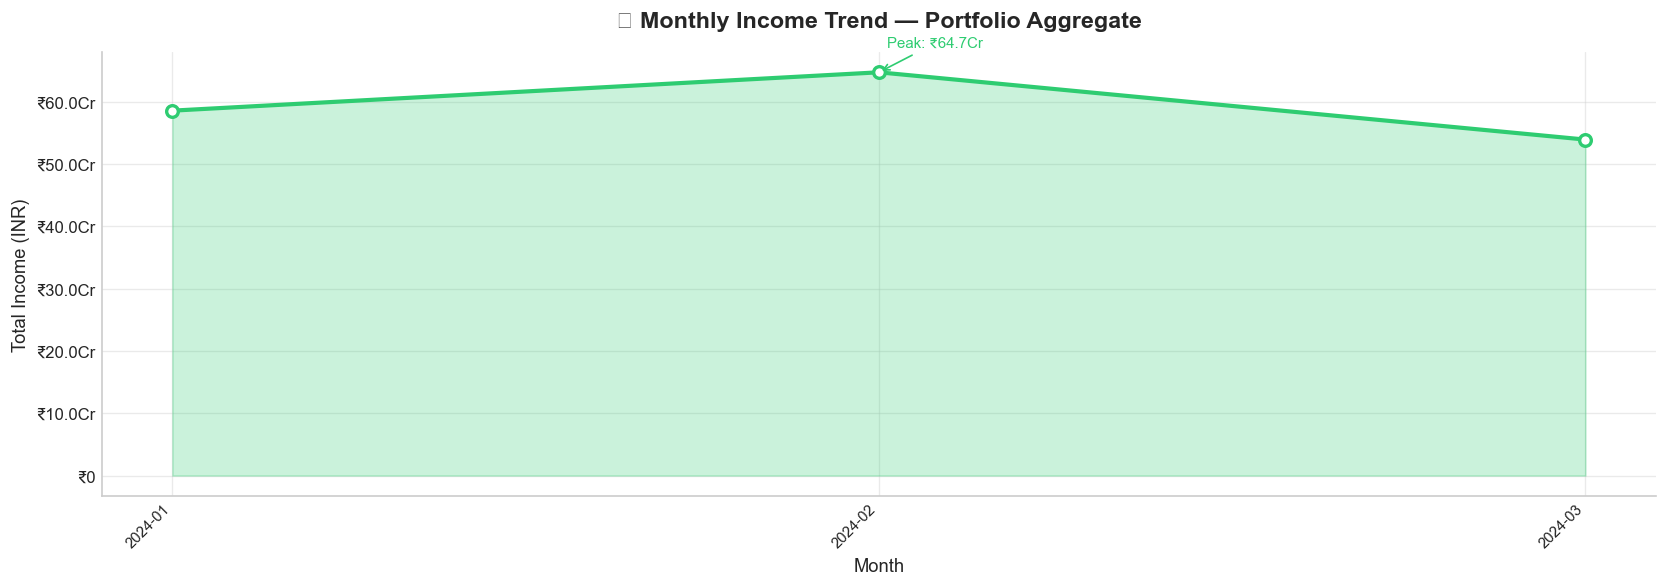

  ✅ Chart 1: Monthly Income Trend saved.


In [27]:
# ── Chart 1: Monthly Income Trend ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=FIGURE_SIZE, dpi=FIGURE_DPI)

ax.fill_between(x, monthly_agg['total_income'],
                alpha=0.25, color=COLORS['income'])
ax.plot(x, monthly_agg['total_income'],
        marker='o', linewidth=2.5, color=COLORS['income'],
        markersize=7, markerfacecolor='white', markeredgewidth=2)

ax.set_title('📈 Monthly Income Trend — Portfolio Aggregate',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Income (INR)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lakh_formatter))
ax.grid(True, alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

# Annotate max income month
max_idx = monthly_agg['total_income'].idxmax()
ax.annotate(
    f"Peak: {lakh_formatter(monthly_agg.loc[max_idx, 'total_income'], None)}",
    xy=(monthly_agg.index.get_loc(max_idx) if max_idx in x else max_idx,
        monthly_agg.loc[max_idx, 'total_income']),
    xytext=(5, 15), textcoords='offset points',
    fontsize=9, color=COLORS['income'],
    arrowprops=dict(arrowstyle='->', color=COLORS['income'])
)

plt.tight_layout()
plt.savefig('chart1_monthly_income_trend.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print("  ✅ Chart 1: Monthly Income Trend saved.")

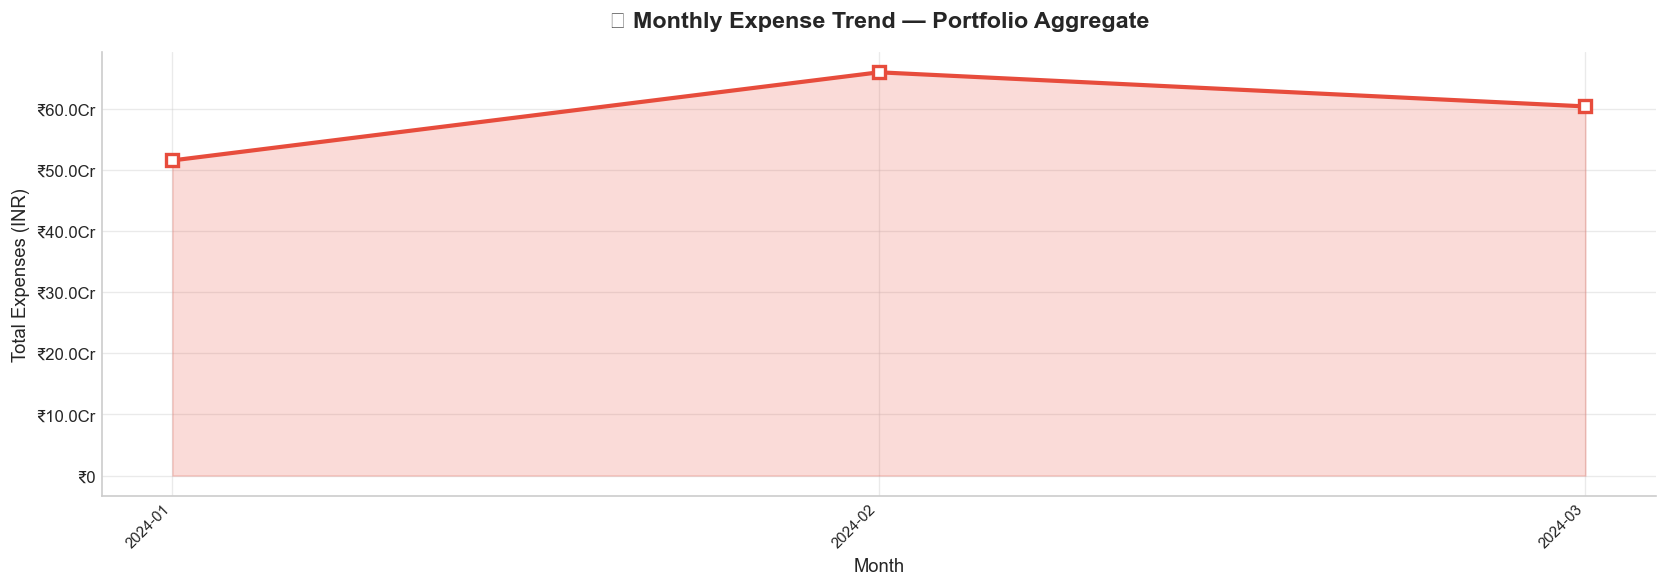

  ✅ Chart 2: Monthly Expense Trend saved.


In [26]:
# ── Chart 2: Monthly Expense Trend ───────────────────────────────────────────

fig, ax = plt.subplots(figsize=FIGURE_SIZE, dpi=FIGURE_DPI)

ax.fill_between(x, monthly_agg['total_expense'],
                alpha=0.2, color=COLORS['expense'])
ax.plot(x, monthly_agg['total_expense'],
        marker='s', linewidth=2.5, color=COLORS['expense'],
        markersize=7, markerfacecolor='white', markeredgewidth=2)

ax.set_title('📉 Monthly Expense Trend — Portfolio Aggregate',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Expenses (INR)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lakh_formatter))
ax.grid(True, alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_monthly_expense_trend.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print("  ✅ Chart 2: Monthly Expense Trend saved.")

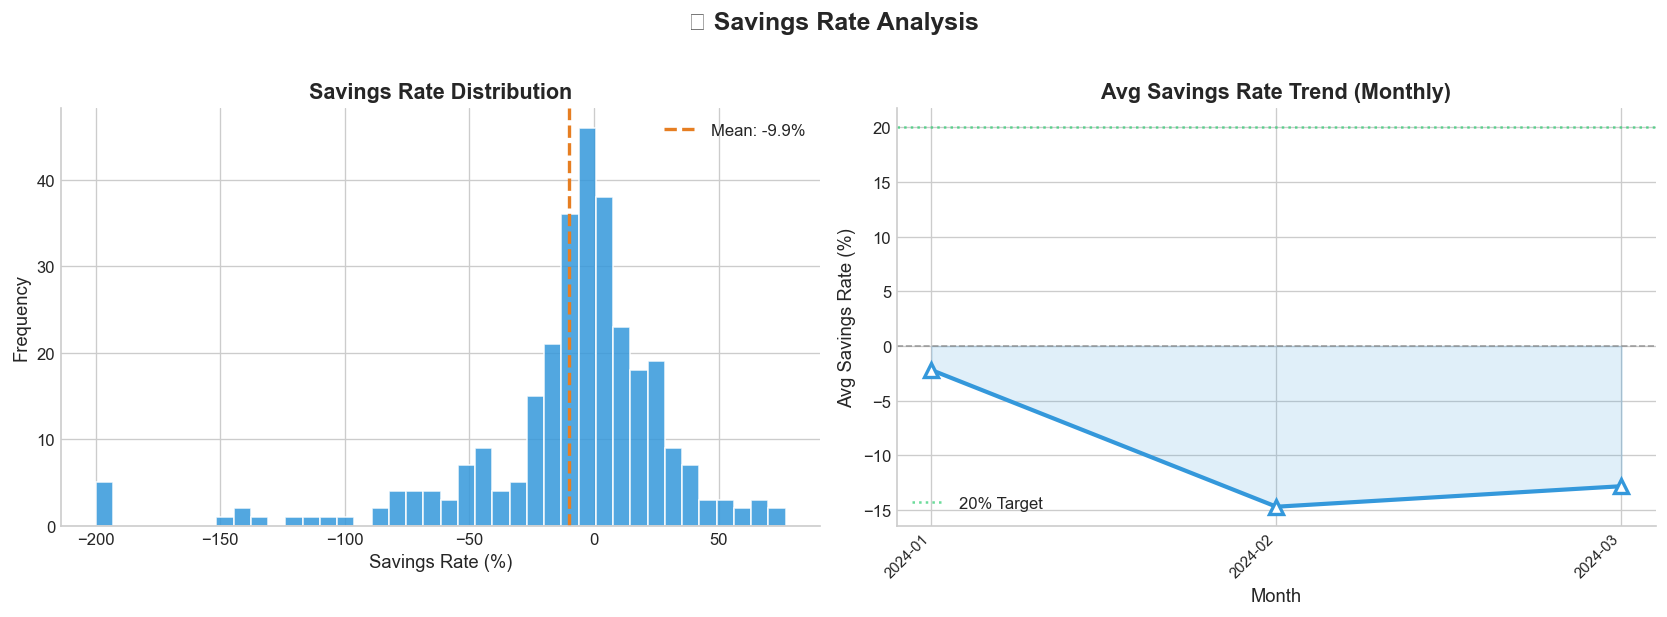

  ✅ Chart 3: Savings Rate Analysis saved.


In [28]:
# ── Chart 3: Savings Rate Distribution ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIGURE_DPI)

# Left: histogram of all savings rates
savings_values = features_df['savings_rate'].dropna()
axes[0].hist(savings_values, bins=40, color=COLORS['savings'],
             edgecolor='white', alpha=0.85)
axes[0].axvline(savings_values.mean(), color=COLORS['alert'],
                linestyle='--', linewidth=2, label=f'Mean: {savings_values.mean():.1f}%')
axes[0].set_title('Savings Rate Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Savings Rate (%)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: Monthly average savings rate trend
axes[1].plot(x, monthly_agg['avg_savings_rate'],
             marker='^', linewidth=2.5, color=COLORS['savings'],
             markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].fill_between(x, monthly_agg['avg_savings_rate'],
                     alpha=0.15, color=COLORS['savings'])
axes[1].axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.7)
axes[1].axhline(20, color=COLORS['income'], linestyle=':', linewidth=1.5,
                alpha=0.7, label='20% Target')
axes[1].set_title('Avg Savings Rate Trend (Monthly)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Avg Savings Rate (%)', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(months, rotation=45, ha='right', fontsize=9)
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('💰 Savings Rate Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_savings_rate.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print("  ✅ Chart 3: Savings Rate Analysis saved.")

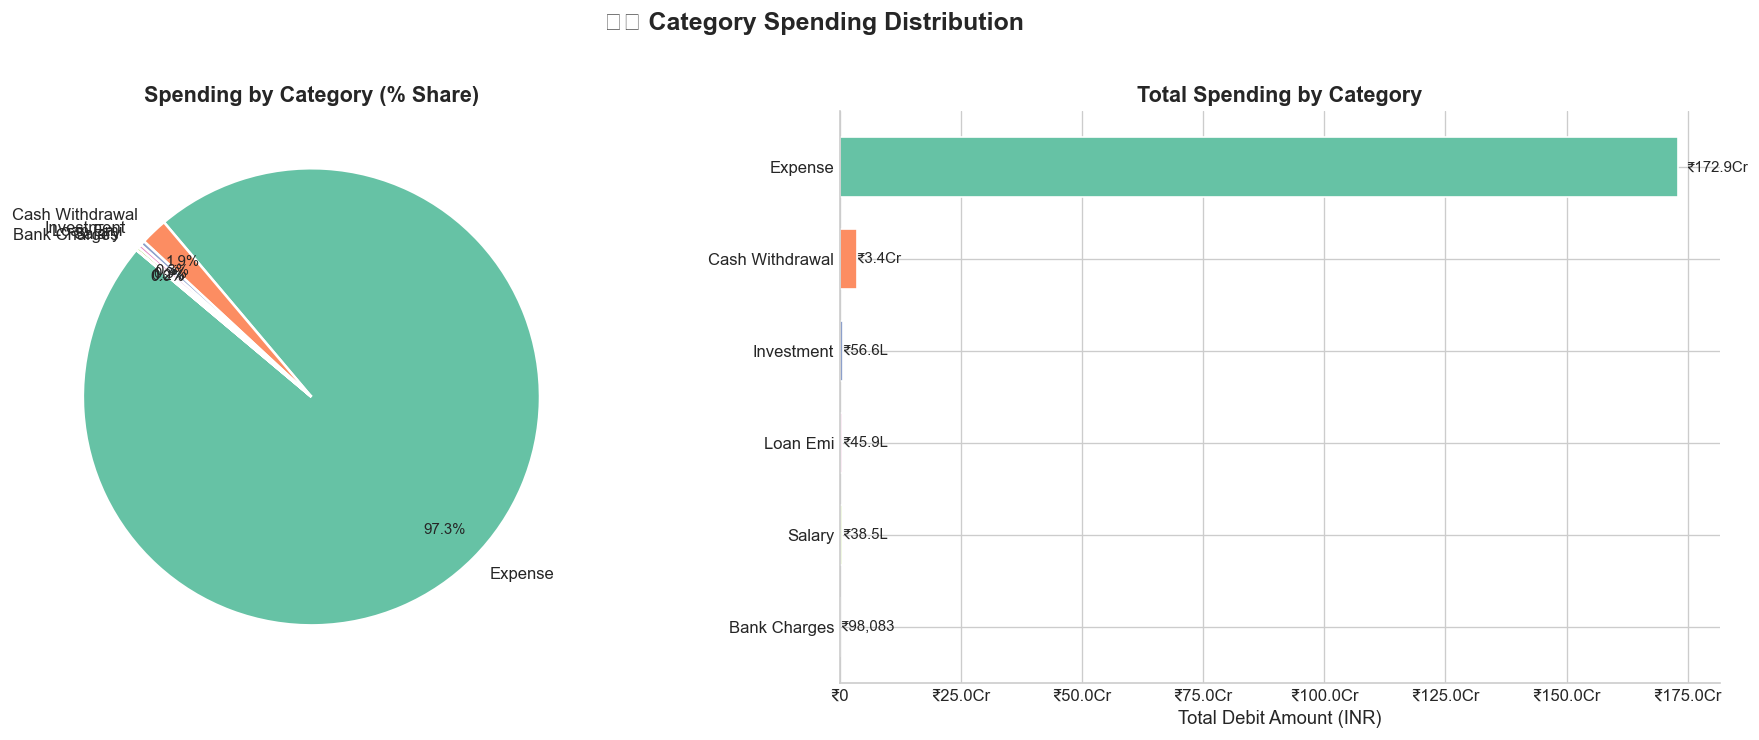

  ✅ Chart 4: Category Distribution saved.


In [29]:
# ── Chart 4: Category Spending Distribution ───────────────────────────────────

# Aggregate debit category columns (spending breakdown)
debit_cat_cols = [c for c in CAT_COLUMNS if c.endswith('_debit')]

if debit_cat_cols:
    cat_totals = features_df[debit_cat_cols].sum().sort_values(ascending=False)
    cat_labels = [c.replace('cat_', '').replace('_debit', '').replace('_', ' ').title()
                  for c in cat_totals.index]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=FIGURE_DPI)

    # Pie chart
    wedge_colors = sns.color_palette('Set2', len(cat_totals))
    wedges, texts, autotexts = axes[0].pie(
        cat_totals.values,
        labels=cat_labels,
        autopct='%1.1f%%',
        colors=wedge_colors,
        startangle=140,
        pctdistance=0.82,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for autotext in autotexts:
        autotext.set_fontsize(9)
    axes[0].set_title('Spending by Category (% Share)',
                      fontsize=13, fontweight='bold')

    # Bar chart
    bars = axes[1].barh(
        cat_labels[::-1], cat_totals.values[::-1],
        color=wedge_colors[::-1], edgecolor='white', height=0.65
    )
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lakh_formatter))
    axes[1].set_xlabel('Total Debit Amount (INR)', fontsize=11)
    axes[1].set_title('Total Spending by Category',
                      fontsize=13, fontweight='bold')
    axes[1].spines[['top', 'right']].set_visible(False)

    # Add value labels on bars
    for bar in bars:
        width = bar.get_width()
        axes[1].text(width * 1.01, bar.get_y() + bar.get_height() / 2,
                     lakh_formatter(width, None),
                     va='center', fontsize=9)

    plt.suptitle('🏷️ Category Spending Distribution',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('chart4_category_distribution.png', dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
    print("  ✅ Chart 4: Category Distribution saved.")
else:
    print("  ⚠️  No debit category columns found. Skipping Chart 4.")

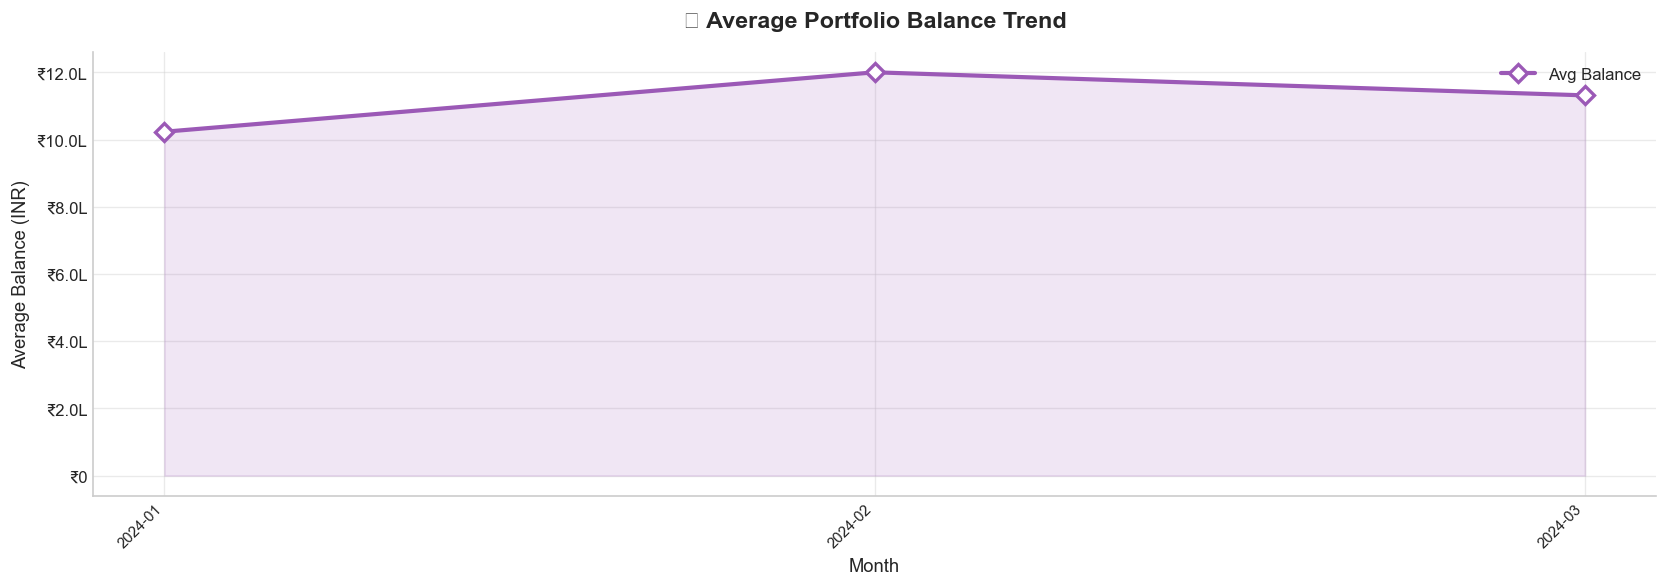

  ✅ Chart 5: Balance Trend saved.


In [30]:
# ── Chart 5: Balance Trend ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=FIGURE_SIZE, dpi=FIGURE_DPI)

ax.plot(x, monthly_agg['avg_balance'],
        marker='D', linewidth=2.5, color=COLORS['balance'],
        markersize=8, markerfacecolor='white', markeredgewidth=2,
        label='Avg Balance')
ax.fill_between(x, monthly_agg['avg_balance'],
                alpha=0.15, color=COLORS['balance'])

ax.set_title('💳 Average Portfolio Balance Trend',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average Balance (INR)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lakh_formatter))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart5_balance_trend.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print("  ✅ Chart 5: Balance Trend saved.")

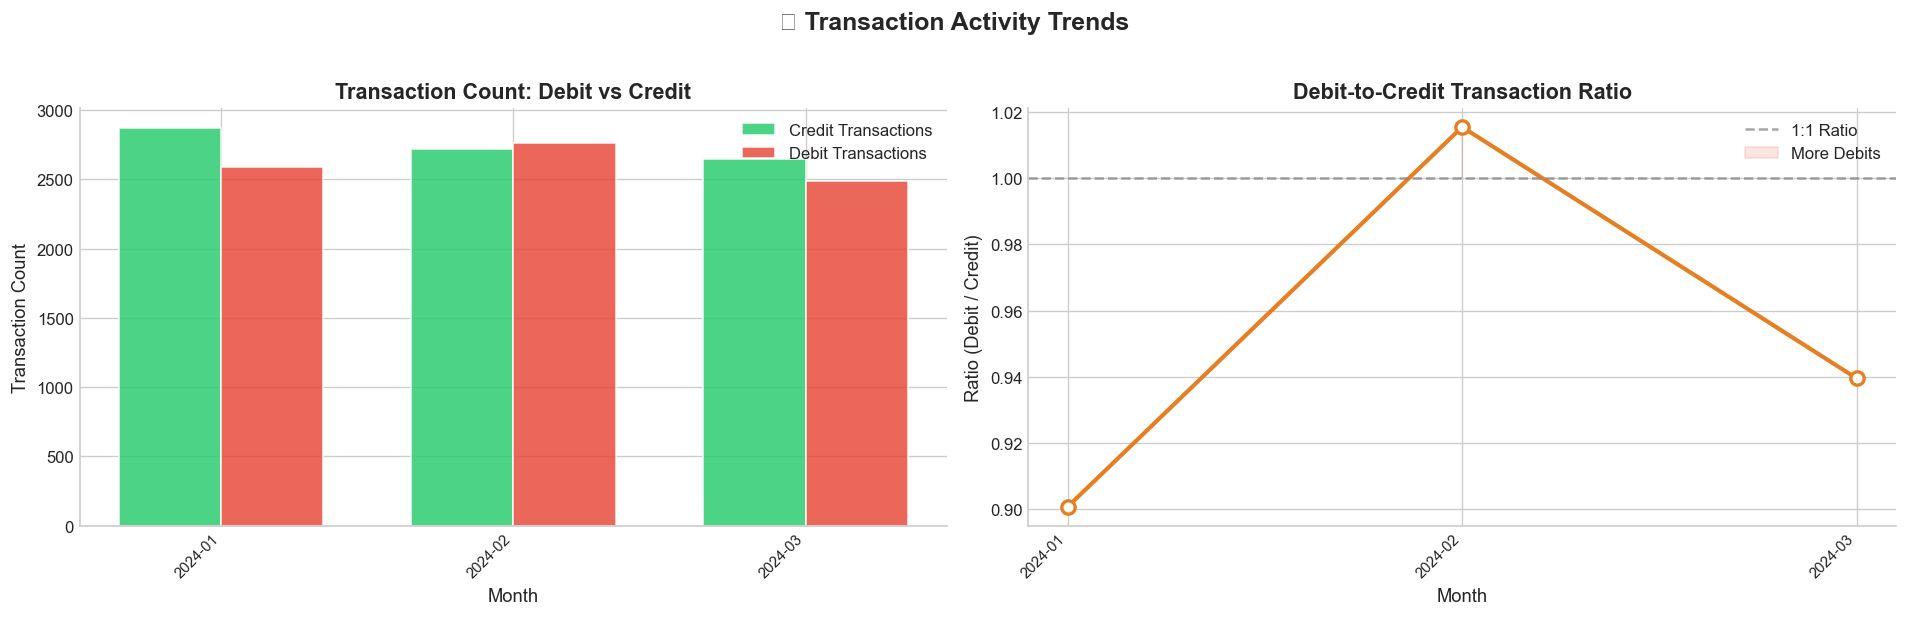

  ✅ Chart 6: Transaction Activity saved.


In [31]:
# ── Chart 6: Transaction Activity Trend ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=FIGURE_DPI)

# Stacked bar: debit vs credit transaction counts
width = 0.35
x_arr = np.array(list(x))

bars_credit = axes[0].bar(
    x_arr - width / 2,
    monthly_agg['total_credit_count'],
    width, label='Credit Transactions',
    color=COLORS['income'], alpha=0.85, edgecolor='white'
)
bars_debit = axes[0].bar(
    x_arr + width / 2,
    monthly_agg['total_debit_count'],
    width, label='Debit Transactions',
    color=COLORS['expense'], alpha=0.85, edgecolor='white'
)
axes[0].set_title('Transaction Count: Debit vs Credit', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=11)
axes[0].set_ylabel('Transaction Count', fontsize=11)
axes[0].set_xticks(x_arr)
axes[0].set_xticklabels(months, rotation=45, ha='right', fontsize=9)
axes[0].legend(fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# Line: ratio of debit to credit
ratio = monthly_agg['total_debit_count'] / (
    monthly_agg['total_credit_count'].replace(0, np.nan)
)
axes[1].plot(x, ratio, marker='o', linewidth=2.5, color=COLORS['alert'],
             markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].axhline(1, color='grey', linestyle='--', linewidth=1.5,
                alpha=0.7, label='1:1 Ratio')
axes[1].fill_between(x, ratio, 1,
                     where=(ratio > 1),
                     alpha=0.15, color=COLORS['expense'],
                     label='More Debits')
axes[1].set_title('Debit-to-Credit Transaction Ratio', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Ratio (Debit / Credit)', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(months, rotation=45, ha='right', fontsize=9)
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('📊 Transaction Activity Trends',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_transaction_activity.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print("  ✅ Chart 6: Transaction Activity saved.")

In [32]:
print(features_df.shape)

print(features_df.columns.tolist())

features_df.head()

(300, 37)
['account_number', 'month_year', 'monthly_income', 'monthly_expense', 'savings', 'savings_rate', 'average_balance', 'minimum_balance', 'maximum_balance', 'transaction_count', 'debit_transaction_count', 'credit_transaction_count', 'average_transaction_amount', 'income_consistency_score', 'expense_stability_score', 'spending_to_income_ratio', 'cash_withdrawal_frequency', 'salary_dependency_ratio', 'bank_name', 'account_holder', 'account_type', 'currency', 'high_spending_flag', 'high_cash_withdrawal_flag', 'low_savings_flag', 'cat_bank_charges_debit', 'cat_cash_withdrawal_credit', 'cat_cash_withdrawal_debit', 'cat_expense_debit', 'cat_income_credit', 'cat_investment_credit', 'cat_investment_debit', 'cat_loan_emi_credit', 'cat_loan_emi_debit', 'cat_salary_credit', 'cat_salary_debit', 'average_transaction_value']


,account_number,month_year,monthly_income,monthly_expense,savings,savings_rate,average_balance,minimum_balance,maximum_balance,transaction_count,debit_transaction_count,credit_transaction_count,average_transaction_amount,income_consistency_score,expense_stability_score,spending_to_income_ratio,cash_withdrawal_frequency,salary_dependency_ratio,bank_name,account_holder,account_type,currency,high_spending_flag,high_cash_withdrawal_flag,low_savings_flag,cat_bank_charges_debit,cat_cash_withdrawal_credit,cat_cash_withdrawal_debit,cat_expense_debit,cat_income_credit,cat_investment_credit,cat_investment_debit,cat_loan_emi_credit,cat_loan_emi_debit,cat_salary_credit,cat_salary_debit,average_transaction_value
0,11447241261,2024-01,"241,403.35","349,529.10","-108,125.75",-44.79,"81,356.22","13,490.06","214,722.27",49,25,24,"12,059.85",15.47,16.26,1.45,0.31,0.17,Trustmark Bank,INVESTMENT SERVICES INDIA,CURRENT ACCOUNT- GENERAL,INR,0,1,1,0.00,"22,180.71","77,655.81","271,873.29","178,666.55",0.00,0.00,0.00,0.00,"40,556.09",0.00,"12,059.85"
1,11447241261,2024-02,"516,177.76","631,442.12","-115,264.36",-22.33,"99,631.50","-61,061.36","255,554.67",63,29,34,"18,216.19",15.47,16.26,1.22,0.13,0.07,Trustmark Bank,INVESTMENT SERVICES INDIA,CURRENT ACCOUNT- GENERAL,INR,1,0,1,384.40,"15,277.15","17,238.15","613,819.57","414,084.04",0.00,0.00,"50,142.60",0.00,"36,673.97",0.00,"18,216.19"
2,11447241261,2024-03,"59,070.49","53,797.21","5,273.28",8.93,"9,354.23","-61,067.86","20,101.82",44,8,36,"2,565.17",15.47,16.26,0.91,0.11,0.11,Trustmark Bank,INVESTMENT SERVICES INDIA,CURRENT ACCOUNT- GENERAL,INR,0,0,1,6.50,"2,160.26","29,561.12","24,229.59","50,486.75",0.00,0.00,0.00,0.00,"6,423.48",0.00,"2,565.18"
3,12878101014,2024-01,"2,003,050.85","1,854,998.07","148,052.78",7.39,"429,824.51","82,925.47","999,419.14",48,21,26,"80,376.02",0.00,0.00,0.93,0.12,0.01,Paramount Banking Corporation,WELLNESS BRANDS INDIA,CURRENT ACCOUNT- GENERAL,INR,0,0,1,0.00,"57,980.01","48,263.79","1,806,734.28","1,931,316.34",0.00,0.00,0.00,0.00,"13,754.50",0.00,"80,376.02"
4,12878101014,2024-02,"11,504,847.13","11,671,043.91","-166,196.78",-1.44,"1,887,067.41","189,308.50","5,575,145.76",64,41,23,"362,123.30",0.00,0.00,1.01,0.14,0.07,Paramount Banking Corporation,WELLNESS BRANDS INDIA,CURRENT ACCOUNT- GENERAL,INR,1,0,1,197.78,"93,781.04","276,081.49","11,393,807.04","9,935,479.21",0.00,0.00,"631,753.34",957.60,"843,833.54",0.00,"362,123.30"


---

# Section 18 — Export

---

The final feature dataset is exported in two formats:

| Format | Purpose |
|--------|---------|
| `features_dataset.csv` | Primary input for ML models, FastAPI, and Financial Health Score |
| `features_dataset.xlsx` | Human-readable review, stakeholder reporting |

> **Output:** Both files are written to the same directory as this notebook unless a `data/processed/` directory exists.

In [36]:
# =============================================================================
# SECTION 18: EXPORT FEATURE DATASET
# =============================================================================

def export_feature_dataset(
    df: pd.DataFrame,
    base_filename: str = 'features_dataset',
    output_dir: str = None
) -> dict:
    """
    Export the final feature DataFrame to CSV and XLSX formats.

    Output directory resolution (in order of priority):
      1. output_dir parameter (if provided)
      2. data/processed/ (if it exists)
      3. Current notebook directory

    Parameters
    ----------
    df            : pd.DataFrame  Final feature table.
    base_filename : str           Base name for output files (no extension).
    output_dir    : str or None   Override output directory.

    Returns
    -------
    dict  {'csv_path': str, 'xlsx_path': str}
    """
    # ── Resolve output directory ──────────────────────────────────────────────
    if output_dir:
        out_dir = output_dir
    else:
        processed_dir = os.path.join(NOTEBOOK_DIR, 'data', 'processed')
        out_dir = processed_dir if os.path.isdir(processed_dir) else NOTEBOOK_DIR

    os.makedirs(out_dir, exist_ok=True)

    csv_path  = os.path.join(out_dir, f'{base_filename}.csv')
    xlsx_path = os.path.join(out_dir, f'{base_filename}.xlsx')

    # ── Export CSV ────────────────────────────────────────────────────────────
    df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"  ✅ CSV exported  : {csv_path}")
    print(f"     Size          : {os.path.getsize(csv_path) / 1024:.1f} KB")

    # ── Export XLSX ───────────────────────────────────────────────────────────
    try:
        with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
            df.to_excel(writer, sheet_name='features_dataset', index=False)

            # Format: freeze header row and auto-size columns
            ws = writer.sheets['features_dataset']
            ws.freeze_panes = 'A2'

            for col in ws.columns:
                max_len = max(
                    (len(str(cell.value)) for cell in col if cell.value),
                    default=10
                )
                ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 30)

        print(f"  ✅ XLSX exported : {xlsx_path}")
        print(f"     Size          : {os.path.getsize(xlsx_path) / 1024:.1f} KB")

    except ImportError:
        print("  ⚠️  openpyxl not available. Skipping XLSX export.")
        print("      Install with: pip install openpyxl>=3.1.5")
        xlsx_path = None

    return {'csv_path': csv_path, 'xlsx_path': xlsx_path}


print("📦 Exporting features_dataset...\n")
export_paths = export_feature_dataset(features_df)

print(f"\n🎉 Export complete!")
print(f"   Rows     : {features_df.shape[0]:,}")
print(f"   Columns  : {features_df.shape[1]}")
print(f"   CSV Path : {export_paths['csv_path']}")
if export_paths['xlsx_path']:
    print(f"   XLSX Path: {export_paths['xlsx_path']}")

📦 Exporting features_dataset...

  ✅ CSV exported  : e:\WealthWise-AI\features_dataset.csv
     Size          : 103.8 KB
  ⚠️  openpyxl not available. Skipping XLSX export.
      Install with: pip install openpyxl>=3.1.5

🎉 Export complete!
   Rows     : 300
   Columns  : 37
   CSV Path : e:\WealthWise-AI\features_dataset.csv


In [37]:
# =============================================================================
# FINAL SUMMARY REPORT
# =============================================================================

print("="*65)
print("  🏆 WealthWise AI — Feature Engineering Complete")
print("="*65)

print(f"""
  📊 Dataset Summary
  ─────────────────────────────────────────────────────────────
  Input: Transactions     : {txn_df.shape[0]:>8,} rows × {txn_df.shape[1]} columns
  Input: Accounts         : {acc_df.shape[0]:>8,} rows × {acc_df.shape[1]} columns
  Input: Bank Statements  : {bs_df.shape[0]:>8,} rows × {bs_df.shape[1]} columns
  Output: Feature Table   : {features_df.shape[0]:>8,} rows × {features_df.shape[1]} columns

  🔢 Feature Group Summary
  ─────────────────────────────────────────────────────────────
  Core financial features   : monthly_income, monthly_expense,
                              savings, savings_rate
  Balance features          : average_balance, minimum_balance,
                              maximum_balance
  Activity features         : transaction_count,
                              debit_transaction_count,
                              credit_transaction_count,
                              average_transaction_amount
  Stability features        : income_consistency_score,
                              expense_stability_score
  Behaviour features        : spending_to_income_ratio,
                              average_transaction_value,
                              cash_withdrawal_frequency,
                              salary_dependency_ratio
  Smart alert flags         : high_spending_flag,
                              high_cash_withdrawal_flag,
                              low_savings_flag
  Category features         : {len(CAT_COLUMNS)} auto-generated category columns

  📁 Output Files
  ─────────────────────────────────────────────────────────────
  features_dataset.csv     ✅
  features_dataset.xlsx    ✅

  🔮 Next Steps
  ─────────────────────────────────────────────────────────────
  → 03_financial_health_score.ipynb
  → 04_ml_risk_classification.ipynb  (Random Forest)
  → 05_portfolio_recommendation.ipynb
  → 06_ai_financial_coach.ipynb      (Gemini API)
  → 07_dashboard.ipynb               (WealthWise Analytics)
""")

print("="*65)

  🏆 WealthWise AI — Feature Engineering Complete

  📊 Dataset Summary
  ─────────────────────────────────────────────────────────────
  Input: Transactions     :   16,204 rows × 14 columns
  Input: Accounts         :      100 rows × 17 columns
  Input: Bank Statements  :      100 rows × 17 columns
  Output: Feature Table   :      300 rows × 37 columns

  🔢 Feature Group Summary
  ─────────────────────────────────────────────────────────────
  Core financial features   : monthly_income, monthly_expense,
                              savings, savings_rate
  Balance features          : average_balance, minimum_balance,
                              maximum_balance
  Activity features         : transaction_count,
                              debit_transaction_count,
                              credit_transaction_count,
                              average_transaction_amount
  Stability features        : income_consistency_score,
                              expense_stability_score
  B